In [3]:
import pandas as pd

# Source requested: GUI day-ahead Belgium price export
file_path = "GUI_ENERGY_PRICES_202412312300-202512312300.csv"
target_year = 2025

start_utc = pd.Timestamp(f"{target_year}-01-01 00:00:00", tz="UTC")
end_utc = pd.Timestamp(f"{target_year + 1}-01-01 00:00:00", tz="UTC")

raw = pd.read_csv(file_path)
required_cols = ["MTU (CET/CEST)", "Area", "Day-ahead Price (EUR/MWh)"]
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required GUI columns: {missing}")

# Parse start of MTU interval in Europe/Brussels and convert to UTC
mtu_start = raw["MTU (CET/CEST)"].astype(str).str.split(" - ").str[0]
dt_local = pd.to_datetime(mtu_start, dayfirst=True, errors="coerce")
try:
    dt_utc = dt_local.dt.tz_localize("Europe/Brussels", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert("UTC")
except Exception:
    dt_utc = dt_local.dt.tz_localize("Europe/Brussels", ambiguous="NaT", nonexistent="shift_forward").dt.tz_convert("UTC")

work = raw.copy()
work["Datetime (UTC)"] = dt_utc
work = work.dropna(subset=["Datetime (UTC)"])
work = work[(work["Datetime (UTC)"] >= start_utc) & (work["Datetime (UTC)"] < end_utc)].copy()

# Keep Belgium bidding zone rows where available
if "Area" in work.columns:
    be_mask = work["Area"].astype(str).str.contains(r"BZN\|BE", regex=True, na=False)
    if be_mask.any():
        work = work.loc[be_mask].copy()

work["Price (EUR/MWhe)"] = pd.to_numeric(work["Day-ahead Price (EUR/MWh)"], errors="coerce")
work = work.dropna(subset=["Price (EUR/MWhe)"])
work["Country"] = "Belgium"
work["ISO3 Code"] = "BEL"

df_2025 = work[["Country", "ISO3 Code", "Datetime (UTC)", "Price (EUR/MWhe)"]].sort_values("Datetime (UTC)").reset_index(drop=True)

print(df_2025.shape)
print(df_2025.head())

(35026, 4)
   Country ISO3 Code            Datetime (UTC)  Price (EUR/MWhe)
0  Belgium       BEL 2025-01-01 00:00:00+00:00             10.27
1  Belgium       BEL 2025-01-01 00:15:00+00:00             10.27
2  Belgium       BEL 2025-01-01 00:30:00+00:00             10.27
3  Belgium       BEL 2025-01-01 00:45:00+00:00             10.27
4  Belgium       BEL 2025-01-01 01:00:00+00:00              8.38


In [4]:
# Daily average electricity price per country (2025)
df_2025["Date"] = df_2025["Datetime (UTC)"].dt.floor("D")

daily_avg_2025 = (
    df_2025.groupby(["Country", "Date"], as_index=False)["Price (EUR/MWhe)"]
    .mean()
    .rename(columns={"Price (EUR/MWhe)": "Daily Avg Price (EUR/MWhe)"})
    .sort_values(["Country", "Date"], ignore_index=True)
)

print(daily_avg_2025.shape)
print(daily_avg_2025.head())

(365, 3)
   Country                      Date  Daily Avg Price (EUR/MWhe)
0  Belgium 2025-01-01 00:00:00+00:00                   23.627083
1  Belgium 2025-01-02 00:00:00+00:00                  115.652083
2  Belgium 2025-01-03 00:00:00+00:00                  120.500833
3  Belgium 2025-01-04 00:00:00+00:00                  122.087500
4  Belgium 2025-01-05 00:00:00+00:00                   53.136667


In [5]:
# Build balanced daily panel and combined dataset (Europe + country columns)
# 1) Keep country-days with complete intraday coverage
hour_counts = (
    df_2025.assign(Date=df_2025["Datetime (UTC)"].dt.floor("D"))
    .groupby(["Country", "Date"], as_index=False)
    .size()
    .rename(columns={"size": "hours"})
)

if hour_counts.empty:
    raise ValueError("No country-day observations available after filtering df_2025.")

# GUI feed is quarter-hourly (typically 96 points/day), but infer dynamically.
expected_points = int(hour_counts["hours"].mode().iloc[0])
complete_country_days = hour_counts[hour_counts["hours"] == expected_points][["Country", "Date"]]

daily_country_complete = (
    daily_avg_2025
    .merge(complete_country_days, on=["Country", "Date"], how="inner")
    .copy()
)

# 2) Keep only dates with constant country set (balanced panel)
countries_per_day = daily_country_complete.groupby("Date")["Country"].nunique()
if countries_per_day.empty:
    raise ValueError("No balanced daily rows after intraday completeness filter.")

max_countries = int(countries_per_day.max())
all_dates_2025 = countries_per_day[countries_per_day == max_countries].index

balanced_daily_country = daily_country_complete[
    daily_country_complete["Date"].isin(all_dates_2025)
].copy()

# 3) Europe daily average from balanced panel
europe_daily_avg_2025 = (
    balanced_daily_country.groupby("Date", as_index=False)["Daily Avg Price (EUR/MWhe)"]
    .mean()
    .rename(columns={"Daily Avg Price (EUR/MWhe)": "Europe Daily Avg Price (EUR/MWhe)"})
)

# 4) Wide country matrix + Europe
country_daily_wide = (
    balanced_daily_country
    .pivot(index="Date", columns="Country", values="Daily Avg Price (EUR/MWhe)")
    .sort_index()
)
country_daily_wide = country_daily_wide.add_prefix("Country Avg - ")

combined_daily_2025 = (
    europe_daily_avg_2025
    .set_index("Date")
    .join(country_daily_wide, how="inner")
    .reset_index()
    .sort_values("Date", ignore_index=True)
)

print("Expected intraday points/day:", expected_points)
print("Balanced countries per day:", max_countries)
print("Balanced dates:", len(all_dates_2025))
print(combined_daily_2025.shape)
print(combined_daily_2025.head())

Expected intraday points/day: 96
Balanced countries per day: 1
Balanced dates: 362
(362, 3)
                       Date  Europe Daily Avg Price (EUR/MWhe)  \
0 2025-01-01 00:00:00+00:00                          23.627083   
1 2025-01-02 00:00:00+00:00                         115.652083   
2 2025-01-03 00:00:00+00:00                         120.500833   
3 2025-01-04 00:00:00+00:00                         122.087500   
4 2025-01-05 00:00:00+00:00                          53.136667   

   Country Avg - Belgium  
0              23.627083  
1             115.652083  
2             120.500833  
3             122.087500  
4              53.136667  


In [6]:
# Belgium daily weather (2025) using Open-Meteo, merged to energy dataset
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# Set up a cached + retried API client
cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Brussels as a Belgium proxy
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 50.8503,
    "longitude": 4.3517,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": ["temperature_2m_mean", "temperature_2m_min", "temperature_2m_max", "precipitation_sum", "wind_speed_10m_mean"],
    "timezone": "UTC"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
daily = response.Daily()

belgium_weather_2025 = pd.DataFrame({
    "Date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "BE Temp Avg (C)": daily.Variables(0).ValuesAsNumpy(),
    "BE Temp Min (C)": daily.Variables(1).ValuesAsNumpy(),
    "BE Temp Max (C)": daily.Variables(2).ValuesAsNumpy(),
    "BE Precipitation (mm)": daily.Variables(3).ValuesAsNumpy(),
    "BE Wind Speed (km/h)": daily.Variables(4).ValuesAsNumpy(),
})

combined_daily_2025_with_be_weather = combined_daily_2025.merge(
    belgium_weather_2025,
    on="Date",
    how="left"
)

print(belgium_weather_2025.head())
print(combined_daily_2025_with_be_weather.shape)
print(combined_daily_2025_with_be_weather.head())

                       Date  BE Temp Avg (C)  BE Temp Min (C)  \
0 2025-01-01 00:00:00+00:00         6.604167             2.95   
1 2025-01-02 00:00:00+00:00         2.904167             0.90   
2 2025-01-03 00:00:00+00:00         0.687500            -1.05   
3 2025-01-04 00:00:00+00:00         1.004167            -0.65   
4 2025-01-05 00:00:00+00:00         7.585416             0.80   

   BE Temp Max (C)  BE Precipitation (mm)  BE Wind Speed (km/h)  
0             8.80              11.000000             27.924313  
1             5.45               8.000000             10.333981  
2             2.70               0.000000             13.145383  
3             2.30               0.100000              9.542207  
4            11.60              26.399998             22.833347  
(362, 8)
                       Date  Europe Daily Avg Price (EUR/MWhe)  \
0 2025-01-01 00:00:00+00:00                          23.627083   
1 2025-01-02 00:00:00+00:00                         115.652083   
2 2025

In [7]:
# Daily weather compatibility frame (2025)
# Keep a timestamp-based view for downstream cells that expect this variable name.
if "belgium_weather_2025" not in globals() or belgium_weather_2025.empty:
    raise ValueError("Run the Belgium daily weather cell first.")

belgium_weather_hourly_pm = belgium_weather_2025.rename(
    columns={
        "Date": "timestamp",
        "BE Temp Avg (C)": "BE Temp (C)",
    }
).copy()

# Ensure UTC-aware daily timestamp
belgium_weather_hourly_pm["timestamp"] = pd.to_datetime(
    belgium_weather_hourly_pm["timestamp"], utc=True, errors="coerce"
).dt.floor("D")

keep_cols = ["timestamp", "BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
existing_cols = [c for c in keep_cols if c in belgium_weather_hourly_pm.columns]
belgium_weather_hourly_pm = belgium_weather_hourly_pm[existing_cols].dropna(subset=["timestamp"]).reset_index(drop=True)

print("Daily weather compatibility frame prepared:", belgium_weather_hourly_pm.shape)
print(belgium_weather_hourly_pm.head())

Daily weather compatibility frame prepared: (365, 4)
                  timestamp  BE Temp (C)  BE Precipitation (mm)  \
0 2025-01-01 00:00:00+00:00     6.604167              11.000000   
1 2025-01-02 00:00:00+00:00     2.904167               8.000000   
2 2025-01-03 00:00:00+00:00     0.687500               0.000000   
3 2025-01-04 00:00:00+00:00     1.004167               0.100000   
4 2025-01-05 00:00:00+00:00     7.585416              26.399998   

   BE Wind Speed (km/h)  
0             27.924313  
1             10.333981  
2             13.145383  
3              9.542207  
4             22.833347  


In [8]:
# CSV-only: hourly Russia-Ukraine peace market data (last month)
from pathlib import Path
import pandas as pd

csv_candidates = [
    "pm_russia_ukraine_peace_parlay_hourly_last_month.csv",
    "pm_russia_ukraine_peace_parlay_hourly_last_month_wide.csv",
    "pm_hourly_last_month_pipeline_wide.csv",
]

chosen_path = None
for p in csv_candidates:
    if Path(p).exists():
        chosen_path = p
        break

if chosen_path is None:
    raise FileNotFoundError(
        "No local PM hourly CSV found. Expected one of: " + ", ".join(csv_candidates)
    )

pm_hourly_last_month = pd.read_csv(chosen_path)

required_cols = {"timestamp", "price_Yes", "price_No"}
missing = required_cols - set(pm_hourly_last_month.columns)
if missing:
    raise ValueError(f"Missing required columns in {chosen_path}: {sorted(missing)}")

pm_hourly_last_month["timestamp"] = pd.to_datetime(
    pm_hourly_last_month["timestamp"], utc=True, errors="coerce"
)
pm_hourly_last_month = (
    pm_hourly_last_month
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Keep compatibility with downstream references
now_utc = pd.Timestamp.now(tz="UTC").floor("h")
window_start = now_utc - pd.Timedelta(days=29)
selected_market = {
    "id": "csv_source",
    "question": "Russia x Ukraine Peace Parlay (from local CSV)",
    "title": "Russia x Ukraine Peace Parlay (from local CSV)",
    "slug": "russia-ukraine-peace-parlay-csv",
}
source_used = f"local_csv:{chosen_path}"
scored_candidates = []
candidate_markets = [selected_market]

print("Selected market:", selected_market["question"])
print("Market id:", selected_market["id"])
print("Data source used:", source_used)
print("Rows:", pm_hourly_last_month.shape)
print(pm_hourly_last_month.head())

Selected market: Russia x Ukraine Peace Parlay (from local CSV)
Market id: csv_source
Data source used: local_csv:pm_russia_ukraine_peace_parlay_hourly_last_month.csv
Rows: (50, 3)
                  timestamp  price_No  price_Yes
0 2026-02-26 12:00:00+00:00  0.760526   0.239474
1 2026-02-26 13:00:00+00:00  0.760000   0.240000
2 2026-02-26 14:00:00+00:00  0.760000   0.240000
3 2026-02-26 15:00:00+00:00  0.760000   0.240000
4 2026-02-26 16:00:00+00:00  0.760000   0.240000


In [9]:
# CSV-only retry alias: provide compatibility variables without API calls
import pandas as pd

if "pm_hourly_last_month" not in globals() or pm_hourly_last_month is None or pm_hourly_last_month.empty:
    raise ValueError("Run the CSV-only PM hourly load cell first.")

pm_hourly_last_month_retry2 = pm_hourly_last_month.copy()
selected_market_retry2 = {
    "id": "csv_source",
    "question": "Russia x Ukraine Peace Parlay (from local CSV)",
    "slug": "russia-ukraine-peace-parlay-csv",
}
attempt_log2 = [("csv_source", selected_market_retry2["question"], len(pm_hourly_last_month_retry2))]
candidates = []

print("Candidates found:", len(candidates))
print("Top attempted (id, question, status/rows):")
for row in attempt_log2[:12]:
    print(row)

print("\nSelected market:", selected_market_retry2.get("question") or selected_market_retry2.get("slug"))
print("Rows:", pm_hourly_last_month_retry2.shape)
print(pm_hourly_last_month_retry2.head())

Candidates found: 0
Top attempted (id, question, status/rows):
('csv_source', 'Russia x Ukraine Peace Parlay (from local CSV)', 50)

Selected market: Russia x Ukraine Peace Parlay (from local CSV)
Rows: (50, 3)
                  timestamp  price_No  price_Yes
0 2026-02-26 12:00:00+00:00  0.760526   0.239474
1 2026-02-26 13:00:00+00:00  0.760000   0.240000
2 2026-02-26 14:00:00+00:00  0.760000   0.240000
3 2026-02-26 15:00:00+00:00  0.760000   0.240000
4 2026-02-26 16:00:00+00:00  0.760000   0.240000


In [10]:
# CSV schema debug (replaces remote payload debug)
import pandas as pd

if "pm_hourly_last_month_retry2" in globals() and isinstance(pm_hourly_last_month_retry2, pd.DataFrame) and not pm_hourly_last_month_retry2.empty:
    debug_df = pm_hourly_last_month_retry2.copy()
elif "pm_hourly_last_month" in globals() and isinstance(pm_hourly_last_month, pd.DataFrame) and not pm_hourly_last_month.empty:
    debug_df = pm_hourly_last_month.copy()
else:
    raise ValueError("No PM hourly DataFrame available. Run the CSV-only PM load cell first.")

print("source: local CSV-backed DataFrame")
print("shape:", debug_df.shape)
print("columns:", debug_df.columns.tolist())
print("dtypes:")
print(debug_df.dtypes)
print("head:")
print(debug_df.head())

source: local CSV-backed DataFrame
shape: (50, 3)
columns: ['timestamp', 'price_No', 'price_Yes']
dtypes:
timestamp    datetime64[us, UTC]
price_No                 float64
price_Yes                float64
dtype: object
head:
                  timestamp  price_No  price_Yes
0 2026-02-26 12:00:00+00:00  0.760526   0.239474
1 2026-02-26 13:00:00+00:00  0.760000   0.240000
2 2026-02-26 14:00:00+00:00  0.760000   0.240000
3 2026-02-26 15:00:00+00:00  0.760000   0.240000
4 2026-02-26 16:00:00+00:00  0.760000   0.240000


In [11]:
# Import two daily prediction markets (2025) from local CSVs
import pandas as pd


def load_daily_pm_csv(path, yes_col_name):
    df = pd.read_csv(path)
    required = {"category", "Yes"}
    if not required.issubset(df.columns):
        raise ValueError(f"{path} must contain columns: {required}")

    out = df[["category", "Yes"]].copy()
    out["Date"] = pd.to_datetime(out["category"], utc=True, errors="coerce").dt.floor("D")
    out = out.dropna(subset=["Date"]).rename(columns={"Yes": yes_col_name})
    out[yes_col_name] = pd.to_numeric(out[yes_col_name], errors="coerce")
    out = out.dropna(subset=[yes_col_name])
    out = out[["Date", yes_col_name]].sort_values("Date").drop_duplicates(subset=["Date"], keep="last")
    return out

pm_nuclear = load_daily_pm_csv("NuclearDetonation.csv", "price_Yes_nuclear")
pm_ukraine = load_daily_pm_csv("Ukraine.csv", "price_Yes_ukraine")

# Build 2025 daily PM panel
start_utc = pd.Timestamp("2025-01-01", tz="UTC")
end_utc = pd.Timestamp("2026-01-01", tz="UTC")
daily_index_2025 = pd.DataFrame({"Date": pd.date_range(start_utc, end_utc, freq="D", inclusive="left")})

pm_daily_2025 = (
    daily_index_2025
    .merge(pm_nuclear, on="Date", how="left")
    .merge(pm_ukraine, on="Date", how="left")
    .sort_values("Date", ignore_index=True)
)

# Fill gaps with time interpolation + carry edges for clean daily alignment
for c in ["price_Yes_nuclear", "price_Yes_ukraine"]:
    pm_daily_2025[c] = pm_daily_2025[c].interpolate(method="linear", limit_direction="both")

# Backward-compatible single-market aliases for downstream cells
pm_daily_2025["price_Yes"] = pm_daily_2025[["price_Yes_nuclear", "price_Yes_ukraine"]].mean(axis=1)
pm_daily_2025["price_No"] = 1.0 - pm_daily_2025["price_Yes"]

print("Daily PM panel built:", pm_daily_2025.shape)
print(pm_daily_2025.head())
print(pm_daily_2025.tail())

Daily PM panel built: (365, 5)
                       Date  price_Yes_nuclear  price_Yes_ukraine  price_Yes  \
0 2025-01-01 00:00:00+00:00               0.22               0.70       0.46   
1 2025-01-02 00:00:00+00:00               0.20               0.64       0.42   
2 2025-01-03 00:00:00+00:00               0.19               0.61       0.40   
3 2025-01-04 00:00:00+00:00               0.18               0.60       0.39   
4 2025-01-05 00:00:00+00:00               0.18               0.60       0.39   

   price_No  
0      0.54  
1      0.58  
2      0.60  
3      0.61  
4      0.61  
                         Date  price_Yes_nuclear  price_Yes_ukraine  \
360 2025-12-27 00:00:00+00:00              0.002              0.013   
361 2025-12-28 00:00:00+00:00              0.002              0.007   
362 2025-12-29 00:00:00+00:00              0.001              0.001   
363 2025-12-30 00:00:00+00:00              0.001              0.003   
364 2025-12-31 00:00:00+00:00              0.001 

In [12]:
# Save two-market daily PM data, then build a daily aligned dataset for 2025
if "pm_daily_2025" not in globals() or pm_daily_2025.empty:
    raise ValueError("Run the two-market PM import cell first.")
if "combined_daily_2025_with_be_weather" not in globals() or combined_daily_2025_with_be_weather.empty:
    raise ValueError("Run electricity + weather daily prep cells first.")

pm_csv_path = "pm_two_markets_daily_2025.csv"
pm_daily_2025.to_csv(pm_csv_path, index=False)

energy_daily = combined_daily_2025_with_be_weather.copy()
energy_daily["Date"] = pd.to_datetime(energy_daily["Date"], utc=True, errors="coerce").dt.floor("D")

# Add daily Belgium load factors from local load CSV
load_path = "Belgium 2025 hourly load.csv"
load_raw = pd.read_csv(load_path)
load_required = ["MTU (CET/CEST)", "Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"]
missing_load_cols = [c for c in load_required if c not in load_raw.columns]
if missing_load_cols:
    raise ValueError(f"Missing required load columns in {load_path}: {missing_load_cols}")

load_start = load_raw["MTU (CET/CEST)"].astype(str).str.split(" - ").str[0]
load_dt_local = pd.to_datetime(load_start, dayfirst=True, errors="coerce")
try:
    load_dt_utc = load_dt_local.dt.tz_localize("Europe/Brussels", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert("UTC")
except Exception:
    load_dt_utc = load_dt_local.dt.tz_localize("Europe/Brussels", ambiguous="NaT", nonexistent="shift_forward").dt.tz_convert("UTC")

load_work = load_raw.copy()
load_work["timestamp"] = load_dt_utc
load_work = load_work.dropna(subset=["timestamp"]).copy()
load_work = load_work[(load_work["timestamp"] >= pd.Timestamp("2025-01-01", tz="UTC")) & (load_work["timestamp"] < pd.Timestamp("2026-01-01", tz="UTC"))].copy()

load_work["Actual Total Load (MW)"] = pd.to_numeric(load_work["Actual Total Load (MW)"], errors="coerce")
load_work["Day-ahead Total Load Forecast (MW)"] = pd.to_numeric(load_work["Day-ahead Total Load Forecast (MW)"], errors="coerce")
load_work = load_work.dropna(subset=["Actual Total Load (MW)", "Day-ahead Total Load Forecast (MW)"])
load_work["Date"] = load_work["timestamp"].dt.floor("D")

load_daily = (
    load_work.groupby("Date", as_index=False)
    .agg(
        {
            "Actual Total Load (MW)": "mean",
            "Day-ahead Total Load Forecast (MW)": "mean",
        }
    )
    .sort_values("Date")
)
load_daily["pct_BE_actual_load"] = load_daily["Actual Total Load (MW)"].pct_change() * 100
load_daily["pct_BE_forecast_load"] = load_daily["Day-ahead Total Load Forecast (MW)"].pct_change() * 100
load_daily["pct_BE_forecast_vs_actual_load"] = (
    load_daily["Day-ahead Total Load Forecast (MW)"] / load_daily["Actual Total Load (MW)"] - 1.0
) * 100

load_keep = ["Date", "pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]
energy_daily = energy_daily.merge(load_daily[load_keep], on="Date", how="left")

# Select Belgium daily electricity level with robust fallback names
belgium_candidates = [
    "Country Avg - Belgium",
    "Daily Avg Price (EUR/MWhe)",
    "Country Hourly - Belgium",
]
belgium_col = next((c for c in belgium_candidates if c in energy_daily.columns), None)
if belgium_col is None:
    raise ValueError("Could not find Belgium daily electricity column in combined_daily_2025_with_be_weather.")

daily_aligned = (
    pm_daily_2025
    .merge(energy_daily, on="Date", how="left")
    .sort_values("Date", ignore_index=True)
)

# Keep columns needed downstream and create backward-compatible names
if belgium_col != "Country Hourly - Belgium":
    daily_aligned["Country Hourly - Belgium"] = daily_aligned[belgium_col]
if "BE Temp (C)" not in daily_aligned.columns and "BE Temp Avg (C)" in daily_aligned.columns:
    daily_aligned["BE Temp (C)"] = daily_aligned["BE Temp Avg (C)"]

# Use timestamp name expected by later cells
daily_aligned["timestamp"] = pd.to_datetime(daily_aligned["Date"], utc=True, errors="coerce").dt.floor("D")

preferred_cols = [
    "timestamp",
    "price_No",
    "price_Yes",
    "price_Yes_nuclear",
    "price_Yes_ukraine",
    "Country Hourly - Belgium",
    "BE Temp (C)",
    "BE Precipitation (mm)",
    "BE Wind Speed (km/h)",
    "pct_BE_actual_load",
    "pct_BE_forecast_load",
    "pct_BE_forecast_vs_actual_load",
]
existing_cols = [c for c in preferred_cols if c in daily_aligned.columns]
hourly_aligned = daily_aligned[existing_cols].copy().sort_values("timestamp", ignore_index=True)

aligned_csv_path = "daily_aligned_with_two_pm_2025.csv"
hourly_aligned.to_csv(aligned_csv_path, index=False)

print("Saved:", pm_csv_path)
print("Saved:", aligned_csv_path)
print("Final columns:", hourly_aligned.columns.tolist())
print("daily aligned shape:", hourly_aligned.shape)
print(hourly_aligned.head())

Saved: pm_two_markets_daily_2025.csv
Saved: daily_aligned_with_two_pm_2025.csv
Final columns: ['timestamp', 'price_No', 'price_Yes', 'price_Yes_nuclear', 'price_Yes_ukraine', 'Country Hourly - Belgium', 'BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
daily aligned shape: (365, 12)
                  timestamp  price_No  price_Yes  price_Yes_nuclear  \
0 2025-01-01 00:00:00+00:00      0.54       0.46               0.22   
1 2025-01-02 00:00:00+00:00      0.58       0.42               0.20   
2 2025-01-03 00:00:00+00:00      0.60       0.40               0.19   
3 2025-01-04 00:00:00+00:00      0.61       0.39               0.18   
4 2025-01-05 00:00:00+00:00      0.61       0.39               0.18   

   price_Yes_ukraine  Country Hourly - Belgium  BE Temp (C)  \
0               0.70                 23.627083     6.604167   
1               0.64                115.652083     2.904167   
2     

In [12]:
# UTC audit + alignment for daily PM, electricity, weather, and final aligned dataset

def _ensure_utc(series):
    s = pd.to_datetime(series, errors="coerce")
    if getattr(s.dt, "tz", None) is None:
        return s.dt.tz_localize("UTC")
    return s.dt.tz_convert("UTC")

if "pm_daily_2025" not in globals() or pm_daily_2025.empty:
    raise ValueError("pm_daily_2025 is missing. Run the two-market PM import cell first.")
if "df_2025" not in globals() or df_2025.empty:
    raise ValueError("df_2025 is missing. Run the electricity import cell first.")
if "belgium_weather_2025" not in globals() or belgium_weather_2025.empty:
    raise ValueError("belgium_weather_2025 is missing. Run the weather cell first.")
if "hourly_aligned" not in globals() or hourly_aligned.empty:
    raise ValueError("hourly_aligned is missing. Run the daily alignment cell first.")

# Align all core time columns to UTC
pm_daily_2025["Date"] = _ensure_utc(pm_daily_2025["Date"])
df_2025["Datetime (UTC)"] = _ensure_utc(df_2025["Datetime (UTC)"])
belgium_weather_2025["Date"] = _ensure_utc(belgium_weather_2025["Date"])
hourly_aligned["timestamp"] = _ensure_utc(hourly_aligned["timestamp"])

pm_tz = str(pm_daily_2025["Date"].dt.tz)
elec_tz = str(df_2025["Datetime (UTC)"].dt.tz)
weather_tz = str(belgium_weather_2025["Date"].dt.tz)
final_tz = str(hourly_aligned["timestamp"].dt.tz)

print("PM Date tz:", pm_tz)
print("Electricity Datetime (UTC) tz:", elec_tz)
print("Weather Date tz:", weather_tz)
print("Final DF timestamp tz:", final_tz)

if not all(tz == "UTC" for tz in [pm_tz, elec_tz, weather_tz, final_tz]):
    raise ValueError("One or more time columns are not UTC after alignment.")

print("All core time columns are aligned to UTC.")

PM Date tz: UTC
Electricity Datetime (UTC) tz: UTC
Weather Date tz: UTC
Final DF timestamp tz: UTC
All core time columns are aligned to UTC.


In [13]:
# Build differenced dataset: difference all series, while retaining PM prices in levels too
hourly_aligned_diff = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

# Numeric columns to difference
numeric_cols = [c for c in hourly_aligned_diff.columns if c != "timestamp"]

# First differences
diff_values = hourly_aligned_diff[numeric_cols].diff()
diff_values = diff_values.rename(columns={c: f"d_{c}" for c in numeric_cols})

# Keep PM prices in levels as requested
level_cols = ["timestamp", "price_No", "price_Yes"]
level_cols = [c for c in level_cols if c in hourly_aligned_diff.columns]

hourly_aligned_diff = pd.concat([
    hourly_aligned_diff[level_cols],
    diff_values,
], axis=1)

# Drop first row with NaN diffs
hourly_aligned_diff = hourly_aligned_diff.dropna().reset_index(drop=True)

# Save
hourly_diff_csv_path = "hourly_aligned_with_pm_window_differences.csv"
hourly_aligned_diff.to_csv(hourly_diff_csv_path, index=False)

print("Saved:", hourly_diff_csv_path)
print("Shape:", hourly_aligned_diff.shape)
print("Columns:", hourly_aligned_diff.columns.tolist())
print(hourly_aligned_diff.head())

Saved: hourly_aligned_with_pm_window_differences.csv
Shape: (358, 14)
Columns: ['timestamp', 'price_No', 'price_Yes', 'd_price_No', 'd_price_Yes', 'd_price_Yes_nuclear', 'd_price_Yes_ukraine', 'd_Country Hourly - Belgium', 'd_BE Temp (C)', 'd_BE Precipitation (mm)', 'd_BE Wind Speed (km/h)', 'd_pct_BE_actual_load', 'd_pct_BE_forecast_load', 'd_pct_BE_forecast_vs_actual_load']
                  timestamp  price_No  price_Yes  d_price_No  d_price_Yes  \
0 2025-01-03 00:00:00+00:00    0.6000     0.4000      0.0200      -0.0200   
1 2025-01-04 00:00:00+00:00    0.6100     0.3900      0.0100      -0.0100   
2 2025-01-05 00:00:00+00:00    0.6100     0.3900      0.0000       0.0000   
3 2025-01-06 00:00:00+00:00    0.6020     0.3980     -0.0080       0.0080   
4 2025-01-07 00:00:00+00:00    0.6015     0.3985     -0.0005       0.0005   

   d_price_Yes_nuclear  d_price_Yes_ukraine  d_Country Hourly - Belgium  \
0                -0.01               -0.030                    4.848750   
1       

In [14]:
# Percentage-change dataset: put all series on a common scale (%)
# while retaining PM prices in levels
import numpy as np

hourly_aligned_pct = hourly_aligned.copy().sort_values("timestamp").reset_index(drop=True)

level_cols = [
    c
    for c in [
        "timestamp",
        "price_No",
        "price_Yes",
        "price_Yes_nuclear",
        "price_Yes_ukraine",
    ]
    if c in hourly_aligned_pct.columns
]
numeric_cols = [c for c in hourly_aligned_pct.columns if c not in level_cols]

# pct_change gives fractional changes; multiply by 100 for percent
pct_vals = hourly_aligned_pct[numeric_cols].pct_change() * 100

# Avoid pandas replace edge bug by masking non-finite values directly
pct_vals = pct_vals.mask(~np.isfinite(pct_vals), pd.NA)
pct_vals = pct_vals.rename(columns={c: f"pct_{c}" for c in numeric_cols})

hourly_aligned_pct = pd.concat([
    hourly_aligned_pct[level_cols],
    pct_vals,
], axis=1)

# Keep rows where at least one pct-change feature is valid
pct_cols = [c for c in hourly_aligned_pct.columns if c.startswith("pct_")]
hourly_aligned_pct = hourly_aligned_pct.dropna(how="all", subset=pct_cols).reset_index(drop=True)

hourly_pct_csv_path = "daily_aligned_with_two_pm_2025_pct_changes.csv"
hourly_aligned_pct.to_csv(hourly_pct_csv_path, index=False)

print("Saved:", hourly_pct_csv_path)
print("Shape:", hourly_aligned_pct.shape)
print("Columns:", hourly_aligned_pct.columns.tolist())
print(hourly_aligned_pct.head())

Saved: daily_aligned_with_two_pm_2025_pct_changes.csv
Shape: (359, 12)
Columns: ['timestamp', 'price_No', 'price_Yes', 'price_Yes_nuclear', 'price_Yes_ukraine', 'pct_Country Hourly - Belgium', 'pct_BE Temp (C)', 'pct_BE Precipitation (mm)', 'pct_BE Wind Speed (km/h)', 'pct_pct_BE_actual_load', 'pct_pct_BE_forecast_load', 'pct_pct_BE_forecast_vs_actual_load']
                  timestamp  price_No  price_Yes  price_Yes_nuclear  \
0 2025-01-02 00:00:00+00:00     0.580      0.420               0.20   
1 2025-01-03 00:00:00+00:00     0.600      0.400               0.19   
2 2025-01-04 00:00:00+00:00     0.610      0.390               0.18   
3 2025-01-05 00:00:00+00:00     0.610      0.390               0.18   
4 2025-01-06 00:00:00+00:00     0.602      0.398               0.19   

   price_Yes_ukraine  pct_Country Hourly - Belgium  pct_BE Temp (C)  \
0              0.640                    389.489463       -56.025230   
1              0.610                      4.192531       -76.327118   

## Daily Factor Model and Idiosyncratic Returns
Construct Belgium electricity idiosyncratic returns from daily electricity returns after removing weather and load factor structure.

In [13]:
# Build BEL idiosyncratic returns from an in-cell PCA factor model (idempotent)
import numpy as np
import pandas as pd

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run the alignment cell first.")

target_col = "Country Hourly - Belgium"
if target_col not in hourly_aligned.columns:
    raise ValueError(f"Missing target column: {target_col}")

# Enforce factor model inputs: weather + load factors
weather_factor_cols = ["BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
load_factor_cols = ["pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]
required_factors = weather_factor_cols + load_factor_cols
missing_factors = [c for c in required_factors if c not in hourly_aligned.columns]
if missing_factors:
    raise ValueError(f"Missing required weather/load factor columns: {missing_factors}")

factor_cols = required_factors

work = hourly_aligned[["timestamp", target_col] + factor_cols].copy().sort_values("timestamp").reset_index(drop=True)
work[[target_col] + factor_cols] = work[[target_col] + factor_cols].interpolate(method="linear", limit_area="inside")
work["BEL_returns"] = work[target_col].pct_change() * 100
ret_df = work[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()

if len(ret_df) < 10:
    raise ValueError(f"Not enough rows to estimate factor model after cleaning: {len(ret_df)}")

# Keep non-constant factors
std = ret_df[factor_cols].std(axis=0, ddof=0)
active = std[std > 0].index.tolist()
if not active:
    raise ValueError("All factor columns are constant after cleaning.")

X = ret_df[active]
y = ret_df["BEL_returns"]
Xz = ((X - X.mean(axis=0)) / X.std(axis=0, ddof=0)).dropna().copy()
y = y.loc[Xz.index]

U, S, _ = np.linalg.svd(Xz.to_numpy(), full_matrices=False)
explained = (S**2) / np.sum(S**2)
n_components = max(1, int(np.searchsorted(np.cumsum(explained), 0.95) + 1))
scores = U * S
X_pca = scores[:, :n_components]

X_design = np.column_stack([np.ones(len(X_pca)), X_pca])
coef = np.linalg.lstsq(X_design, y.to_numpy(), rcond=None)[0]
fitted = X_design @ coef
resid = y.to_numpy() - fitted

model_out = pd.DataFrame(
    {
        "timestamp": ret_df.loc[Xz.index, "timestamp"].to_numpy(),
        "BEL_returns": y.to_numpy(),
        "BEL_fitted": fitted,
        "BEL_idiosyncratic": resid,
    }
)

# Idempotent merge into hourly_aligned
idio_cols = ["BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]
hourly_aligned = hourly_aligned.drop(columns=[c for c in idio_cols if c in hourly_aligned.columns], errors="ignore")
hourly_aligned = hourly_aligned.merge(model_out, on="timestamp", how="left")

print("BEL idiosyncratic series added.")
print("Rows in model_out:", len(model_out))
print("Active factors:", active)
print("PCA components:", n_components)
print(hourly_aligned[["timestamp", "BEL_returns", "BEL_fitted", "BEL_idiosyncratic"]].tail())

BEL idiosyncratic series added.
Rows in model_out: 363
Active factors: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
PCA components: 5
                    timestamp  BEL_returns  BEL_fitted  BEL_idiosyncratic
360 2025-12-27 00:00:00+00:00    -6.773714   76.192885         -82.966599
361 2025-12-28 00:00:00+00:00     2.945702   41.696337         -38.750635
362 2025-12-29 00:00:00+00:00     4.237631   12.352521          -8.114889
363 2025-12-30 00:00:00+00:00    -7.753242   34.740579         -42.493820
364 2025-12-31 00:00:00+00:00          NaN         NaN                NaN


Series: PM_nuclear_returns
Observations: 364


,mean,std,min,max,skew,kurtosis
PM_nuclear_returns,-0.131937,16.755938,-60.0,100.0,1.335911,7.248701


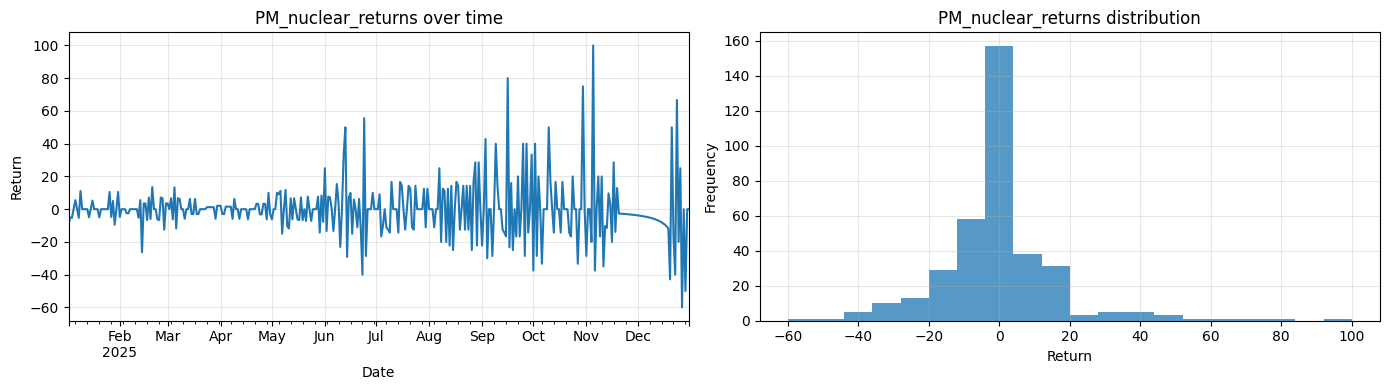

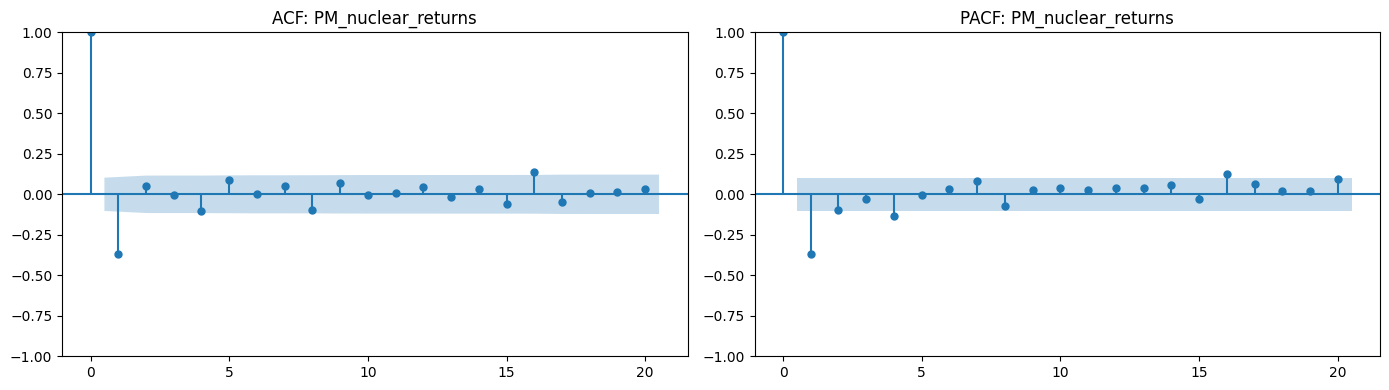

ADF statistic: -12.1695 | p-value: 0.0000
ADF conclusion (5%): Stationary
KPSS statistic: 0.2604 | p-value: 0.1000
KPSS conclusion (5%): Stationary

Series: PM_ukraine_returns
Observations: 364


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_71498/1489672434.py:88: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")


,mean,std,min,max,skew,kurtosis
PM_ukraine_returns,-0.491281,16.753021,-85.714286,200.0,5.061851,63.103123


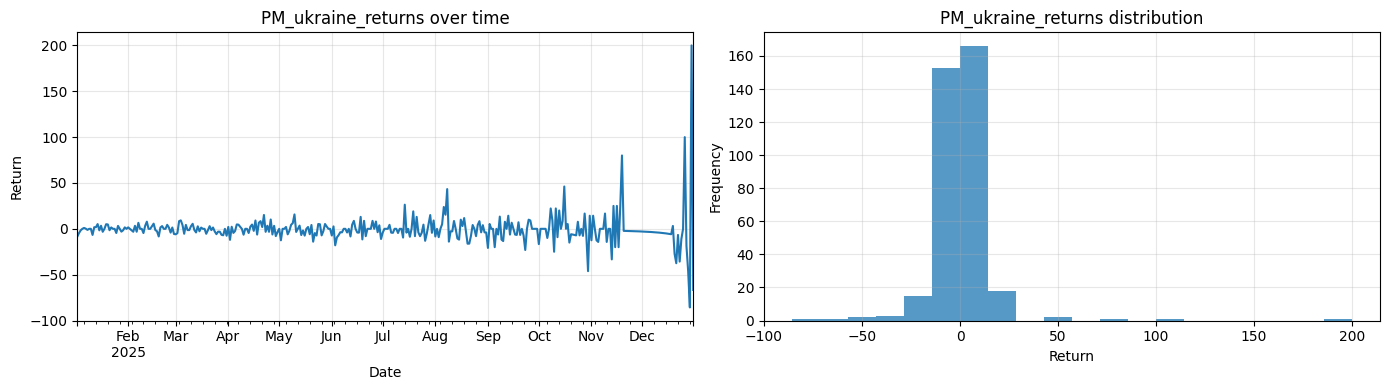

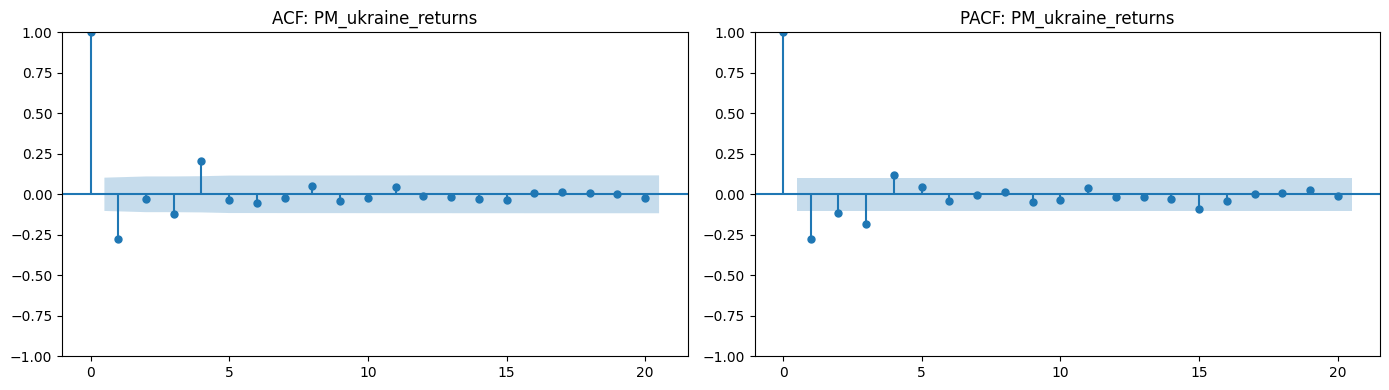

ADF statistic: -6.5489 | p-value: 0.0000
ADF conclusion (5%): Stationary
KPSS statistic: 0.0973 | p-value: 0.1000
KPSS conclusion (5%): Stationary

Series: BEL_idiosyncratic
Observations: 363


/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_71498/1489672434.py:88: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")


,mean,std,min,max,skew,kurtosis
BEL_idiosyncratic,-7.516485e-15,557.675476,-664.394881,10423.553644,18.141613,339.786769


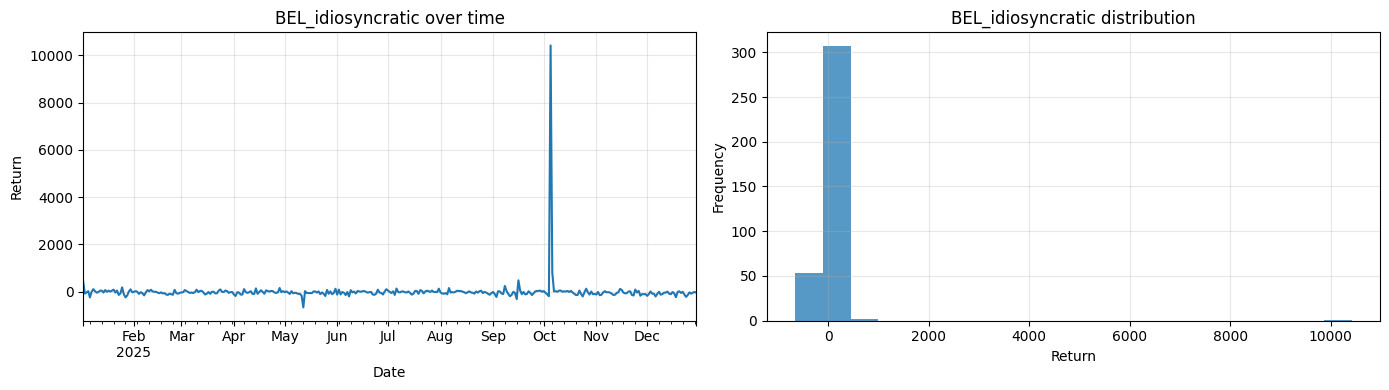

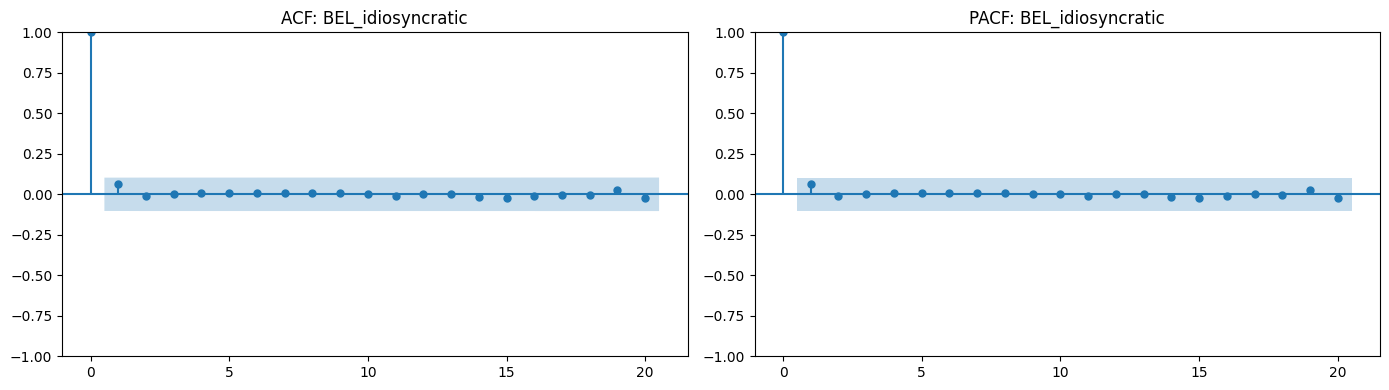

ADF statistic: -17.8233 | p-value: 0.0000
ADF conclusion (5%): Stationary
KPSS statistic: 0.1097 | p-value: 0.1000
KPSS conclusion (5%): Stationary



/var/folders/h9/cypcrhp14dn4gqqq118p8dyh0000gn/T/ipykernel_71498/1489672434.py:88: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")


In [16]:
# ====================================================
# Time-series EDA: two PM return series and Belgian idiosyncratic returns
# Includes autocorrelation and stationarity checks
# ====================================================
import matplotlib.pyplot as plt

try:
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    statsmodels_available = True
except Exception as exc:
    statsmodels_available = False
    print("statsmodels is required for ACF/PACF and ADF/KPSS tests.")
    print("Install with: pip install statsmodels")
    print("Import error:", exc)

required_pm_cols = ["price_Yes_nuclear", "price_Yes_ukraine"]
missing = [c for c in required_pm_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing PM level columns in hourly_aligned: {missing}")

# Build separate prediction-market return series from level prices
pm_returns = hourly_aligned.copy().sort_values("timestamp")
pm_returns["PM_nuclear_returns"] = pm_returns["price_Yes_nuclear"].pct_change() * 100
pm_returns["PM_ukraine_returns"] = pm_returns["price_Yes_ukraine"].pct_change() * 100

series_map = {
    "PM_nuclear_returns": pm_returns.set_index("timestamp")["PM_nuclear_returns"],
    "PM_ukraine_returns": pm_returns.set_index("timestamp")["PM_ukraine_returns"],
    "BEL_idiosyncratic": hourly_aligned.set_index("timestamp").get("BEL_idiosyncratic"),
}

if series_map["BEL_idiosyncratic"] is None:
    raise ValueError("BEL_idiosyncratic not found. Run the Belgian factor model cell first.")

for name, sr in series_map.items():
    sr = sr.dropna().copy()
    if sr.empty:
        print(f"Skipping {name}: no non-NaN observations.")
        continue

    print("=" * 70)
    print(f"Series: {name}")
    print(f"Observations: {len(sr)}")

    desc = pd.DataFrame(
        {
            "mean": [sr.mean()],
            "std": [sr.std()],
            "min": [sr.min()],
            "max": [sr.max()],
            "skew": [sr.skew()],
            "kurtosis": [sr.kurt()],
        },
        index=[name],
    )
    display(desc)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sr.plot(ax=axes[0], title=f"{name} over time")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Return")
    axes[0].grid(alpha=0.3)

    axes[1].hist(sr, bins=20, alpha=0.75)
    axes[1].set_title(f"{name} distribution")
    axes[1].set_xlabel("Return")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if statsmodels_available and len(sr) >= 8:
        max_lags = min(20, max(1, len(sr) // 2 - 1))
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(sr, lags=max_lags, ax=axes[0])
        axes[0].set_title(f"ACF: {name}")
        plot_pacf(sr, lags=max_lags, ax=axes[1], method="ywm")
        axes[1].set_title(f"PACF: {name}")
        plt.tight_layout()
        plt.show()

        adf_stat, adf_p, *_ = adfuller(sr, autolag="AIC")
        print(f"ADF statistic: {adf_stat:.4f} | p-value: {adf_p:.4f}")
        print("ADF conclusion (5%):", "Stationary" if adf_p < 0.05 else "Non-stationary")

        try:
            kpss_stat, kpss_p, *_ = kpss(sr, regression="c", nlags="auto")
            print(f"KPSS statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}")
            print("KPSS conclusion (5%):", "Stationary" if kpss_p >= 0.05 else "Non-stationary")
        except Exception as kpss_exc:
            print("KPSS test failed:", kpss_exc)

        print()
    elif not statsmodels_available:
        print("Skipping ACF/PACF and ADF/KPSS because statsmodels is unavailable.")
    else:
        print("Skipping ACF/PACF and ADF/KPSS due to too few observations.")

## Daily Predictive Modeling
Fit daily models linking prediction-market return series to Belgium idiosyncratic electricity returns.

In [17]:
# ====================================================
# Modeling stage: VAR, SVAR, and ML benchmark
# Target: [PM_nuclear_returns, PM_ukraine_returns] -> BEL_idiosyncratic
# ====================================================

import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# ----------------------------------------------------
# 0) Build modeling dataframe with separate PM drivers
# ----------------------------------------------------
required_cols = ["timestamp", "price_Yes_nuclear", "price_Yes_ukraine", "BEL_idiosyncratic"]
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

ts_raw = hourly_aligned[required_cols].copy()
ts_raw["timestamp"] = pd.to_datetime(ts_raw["timestamp"], utc=True, errors="coerce")
ts_raw = ts_raw.dropna(subset=["timestamp"]).sort_values("timestamp")

# Enforce modeling sample: daily observations over calendar year 2025 only
ts_raw = ts_raw[ts_raw["timestamp"].dt.year == 2025].copy()
if ts_raw.empty:
    raise ValueError("No 2025 observations found in hourly_aligned for fitting.")

# If more than one row exists per day, collapse to a single daily row.
# PM levels use end-of-day (last), idiosyncratic return uses daily mean.
ts_raw["date"] = ts_raw["timestamp"].dt.floor("D")
ts_daily = (
    ts_raw.groupby("date", as_index=False)
    .agg({
        "price_Yes_nuclear": "last",
        "price_Yes_ukraine": "last",
        "BEL_idiosyncratic": "mean",
    })
    .rename(columns={"date": "timestamp"})
)

# Sanity check: frequency must now be one row per day
if ts_daily["timestamp"].duplicated().any():
    raise ValueError("Daily frequency check failed: duplicate dates remain in modeling sample.")

ts_df = ts_daily.copy()
ts_df["PM_nuclear_returns"] = ts_df["price_Yes_nuclear"].pct_change() * 100
ts_df["PM_ukraine_returns"] = ts_df["price_Yes_ukraine"].pct_change() * 100

x_cols = ["PM_nuclear_returns", "PM_ukraine_returns"]
y_col = "BEL_idiosyncratic"
model_cols = x_cols + [y_col]
ts_df = ts_df[["timestamp"] + model_cols].dropna().reset_index(drop=True)

if len(ts_df) < 60:
    raise ValueError(f"Not enough observations for robust model comparison: {len(ts_df)}")

ts_model = ts_df[model_cols].copy()

# Time split: hold out last 10 observations (daily setup)
split_idx = len(ts_model) - 10
if split_idx < 30:
    raise ValueError(f"Training sample too small after 10-step holdout: train={split_idx}")
train_df = ts_model.iloc[:split_idx].copy()
val_df = ts_model.iloc[split_idx:].copy()

span_start = ts_df["timestamp"].min()
span_end = ts_df["timestamp"].max()
print(f"Target relationship: {x_cols} -> {y_col}")
print(f"Fitting frequency: daily | year filter: 2025 | span: {span_start.date()} to {span_end.date()}")
print(f"Total obs: {len(ts_model)} | Train: {len(train_df)} | Validation: {len(val_df)}")
display(ts_df.head())
ts_df = ts_model.copy()

def one_step_from_params(history_window, coefs, intercept):
    yhat = np.array(intercept, dtype=float).copy()
    k_ar = coefs.shape[0]
    for lag in range(1, k_ar + 1):
        yhat += coefs[lag - 1] @ history_window[-lag]
    return yhat

def rolling_forecast_multivariate_from_params(coefs, intercept, train_data, val_data):
    k_ar = coefs.shape[0]
    history = train_data.to_numpy().tolist()
    preds = []
    for i in range(len(val_data)):
        history_window = np.array(history[-k_ar:])
        yhat = one_step_from_params(history_window, coefs, intercept)
        preds.append(yhat)
        history.append(val_data.iloc[i].to_numpy())
    pred_df = pd.DataFrame(preds, index=val_data.index, columns=train_data.columns)
    return pred_df

def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

# -----------------------------
# 1) VAR: tune lag by validation RMSE
# -----------------------------
var_candidates = []
max_lag = min(10, max(2, len(train_df) // 10))

for p in range(1, max_lag + 1):
    try:
        var_fit = VAR(train_df).fit(p)
        var_pred = rolling_forecast_multivariate_from_params(
            var_fit.coefs, var_fit.intercept, train_df, val_df
        )
        score = rmse(val_df[y_col], var_pred[y_col])
        var_candidates.append({"model": "VAR", "lag": p, "val_rmse": score, "fit": var_fit})
    except Exception as exc:
        print(f"VAR lag {p} failed: {exc}")

if not var_candidates:
    raise RuntimeError("All VAR candidates failed.")

best_var = min(var_candidates, key=lambda x: x["val_rmse"])
print(f"Best VAR lag: {best_var['lag']} | Validation RMSE: {best_var['val_rmse']:.6f}")

# -----------------------------
# 2) SVAR: PM returns contemporaneously affect BEL idiosyncratic
# Order: [PM_nuclear_returns, PM_ukraine_returns, BEL_idiosyncratic]
# -----------------------------
svar_candidates = []
A_template = np.array(
    [
        [1, 0, 0],
        ["E", 1, 0],
        ["E", "E", 1],
    ],
    dtype=object,
)

for p in range(1, max_lag + 1):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            svar_mod = SVAR(train_df, svar_type="A", A=A_template)
            svar_fit = svar_mod.fit(
                maxlags=p, ic=None, trend="c", solver="nm", maxiter=3000, maxfun=6000
            )
        p_eff = int(svar_fit.k_ar)
        if p_eff < 1:
            continue
        svar_pred = rolling_forecast_multivariate_from_params(
            svar_fit.coefs, svar_fit.intercept, train_df, val_df
        )
        score = rmse(val_df[y_col], svar_pred[y_col])
        svar_candidates.append({"model": "SVAR", "lag": p_eff, "val_rmse": score, "fit": svar_fit})
    except Exception as exc:
        print(f"SVAR lag {p} failed: {exc}")

if svar_candidates:
    best_svar = min(svar_candidates, key=lambda x: x["val_rmse"])
    print(f"Best SVAR lag: {best_svar['lag']} | Validation RMSE: {best_svar['val_rmse']:.6f}")
else:
    best_svar = None
    print("SVAR candidates failed; check sample size or identification assumptions.")

# -----------------------------
# 3) ML benchmark with both PM predictors
# -----------------------------
def build_lagged_xy(df, target_col, feature_cols, n_lags):
    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        for lag in range(1, n_lags + 1):
            out[f"{col}_lag{lag}"] = df[col].shift(lag)
    out[target_col] = df[target_col]
    out = out.dropna()
    X = out.drop(columns=[target_col])
    y = out[target_col]
    return X, y

def make_estimator(model_name, params):
    if model_name == "Ridge":
        return Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=params["alpha"]))])
    if model_name == "Lasso":
        return Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=params["alpha"], max_iter=20000, random_state=42))])
    if model_name == "ElasticNet":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(alpha=params["alpha"], l1_ratio=params["l1_ratio"], max_iter=20000, random_state=42)),
        ])
    if model_name == "SVR":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(C=params["C"], epsilon=params["epsilon"], gamma=params["gamma"], kernel=params["kernel"])),
        ])
    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "ExtraTrees":
        return ExtraTreesRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "GradientBoosting":
        return GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42,
        )
    raise ValueError(f"Unknown model_name: {model_name}")

ml_model_space = {
    "Ridge": {"alpha": [0.01, 0.1, 1.0, 10.0]},
    "Lasso": {"alpha": [0.001, 0.01, 0.1, 1.0]},
    "ElasticNet": {"alpha": [0.001, 0.01, 0.1], "l1_ratio": [0.2, 0.5, 0.8]},
    "SVR": {
        "C": [0.5, 1.0, 5.0],
        "epsilon": [0.05, 0.1, 0.2],
        "gamma": ["scale"],
        "kernel": ["rbf", "linear"],
    },
    "RandomForest": {
        "n_estimators": [200, 500],
        "max_depth": [3, 5, None],
        "min_samples_leaf": [1, 2],
    },
    "ExtraTrees": {
        "n_estimators": [200, 500],
        "max_depth": [3, 5, None],
        "min_samples_leaf": [1, 2],
    },
    "GradientBoosting": {
        "n_estimators": [150, 300],
        "learning_rate": [0.03, 0.1],
        "max_depth": [2, 3],
    },
}

ml_candidates = []
feature_cols = x_cols + [y_col]
lag_grid = [1, 2, 3, 5]

for n_lags in lag_grid:
    X_all, y_all = build_lagged_xy(ts_df, y_col, feature_cols, n_lags)
    if len(X_all) < 40:
        continue

    split_ml = len(X_all) - 10
    if split_ml < 30:
        continue

    X_train, X_val = X_all.iloc[:split_ml], X_all.iloc[split_ml:]
    y_train, y_val = y_all.iloc[:split_ml], y_all.iloc[split_ml:]

    for model_name, param_space in ml_model_space.items():
        for params in ParameterGrid(param_space):
            try:
                est = make_estimator(model_name, params)
                est.fit(X_train, y_train)
                pred = pd.Series(est.predict(X_val), index=y_val.index)
                score = rmse(y_val, pred)
                ml_candidates.append(
                    {
                        "model": model_name,
                        "lags": n_lags,
                        "params": params,
                        "val_rmse": score,
                        "fit": est,
                        "X_cols": X_train.columns.tolist(),
                    }
                )
            except Exception as exc:
                print(f"{model_name} failed (lags={n_lags}, params={params}): {exc}")

if not ml_candidates:
    raise RuntimeError("All ML candidates failed.")

best_ml = min(ml_candidates, key=lambda x: x["val_rmse"])
print(
    f"Best ML model: {best_ml['model']} | lags={best_ml['lags']} | "
    f"params={best_ml['params']} | Validation RMSE: {best_ml['val_rmse']:.6f}"
)

ml_compare = (
    pd.DataFrame(
        [
            {
                "Model": c["model"],
                "Lags": c["lags"],
                "Params": str(c["params"]),
                "Validation RMSE": c["val_rmse"],
            }
            for c in ml_candidates
        ]
    )
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

print("Top 10 ML configurations:")
display(ml_compare.head(10))

rows = [
    {"Model": "VAR", "Best spec": f"lag={best_var['lag']}", "Validation RMSE": best_var["val_rmse"]},
    {
        "Model": "SVAR",
        "Best spec": f"lag={best_svar['lag']}" if best_svar is not None else "failed",
        "Validation RMSE": best_svar["val_rmse"] if best_svar is not None else np.nan,
    },
    {
        "Model": f"ML ({best_ml['model']})",
        "Best spec": f"lags={best_ml['lags']}, params={best_ml['params']}",
        "Validation RMSE": best_ml["val_rmse"],
    },
]

model_compare = (
    pd.DataFrame(rows)
    .dropna(subset=["Validation RMSE"])
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)
print("Best-fit model ranking (lower RMSE is better):")
display(model_compare)

# Store best models/specs for downstream forecasting comparison
best_models = {
    "VAR": best_var,
    "SVAR": best_svar,
    "ML": best_ml,
    "ML_all_candidates": ml_compare,
    "x_cols": x_cols,
    "x_col": x_cols[0],  # backward compatibility
    "y_col": y_col,
    "train_df": train_df,
    "val_df": val_df,
}


Target relationship: ['PM_nuclear_returns', 'PM_ukraine_returns'] -> BEL_idiosyncratic
Fitting frequency: daily | year filter: 2025 | span: 2025-01-02 to 2025-12-30
Total obs: 363 | Train: 353 | Validation: 10


,timestamp,PM_nuclear_returns,PM_ukraine_returns,BEL_idiosyncratic
0,2025-01-02 00:00:00+00:00,-9.090909,-8.571429,435.813306
1,2025-01-03 00:00:00+00:00,-5.000000,-4.687500,-76.531023
2,2025-01-04 00:00:00+00:00,-5.263158,-1.639344,-34.339273
3,2025-01-05 00:00:00+00:00,0.000000,0.000000,25.123767
4,2025-01-06 00:00:00+00:00,5.555556,1.000000,-242.501661


Best VAR lag: 1 | Validation RMSE: 178.050440
Best SVAR lag: 1 | Validation RMSE: 178.050440
Best ML model: SVR | lags=2 | params={'C': 5.0, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'} | Validation RMSE: 74.589475
Top 10 ML configurations:


,Model,Lags,Params,Validation RMSE
0,SVR,2,"{'C': 5.0, 'epsilon': 0.1, 'gamma': 'scale', '...",74.589475
1,SVR,2,"{'C': 5.0, 'epsilon': 0.2, 'gamma': 'scale', '...",74.631937
2,SVR,2,"{'C': 5.0, 'epsilon': 0.05, 'gamma': 'scale', ...",74.783771
3,SVR,2,"{'C': 0.5, 'epsilon': 0.2, 'gamma': 'scale', '...",77.139883
4,SVR,2,"{'C': 0.5, 'epsilon': 0.1, 'gamma': 'scale', '...",77.254584
5,SVR,2,"{'C': 1.0, 'epsilon': 0.2, 'gamma': 'scale', '...",77.267357
6,SVR,2,"{'C': 0.5, 'epsilon': 0.05, 'gamma': 'scale', ...",77.278085
7,SVR,2,"{'C': 1.0, 'epsilon': 0.1, 'gamma': 'scale', '...",77.294280
8,SVR,2,"{'C': 1.0, 'epsilon': 0.05, 'gamma': 'scale', ...",77.314330
9,GradientBoosting,1,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est...",77.374625


Best-fit model ranking (lower RMSE is better):


,Model,Best spec,Validation RMSE
0,ML (SVR),"lags=2, params={'C': 5.0, 'epsilon': 0.1, 'gam...",74.589475
1,VAR,lag=1,178.050440
2,SVAR,lag=1,178.050440


### Single-Market Attribution
Compare Ukraine-only and Nuclear-only PM driver models for fit and shock sensitivity versus idiosyncratic electricity returns.

Best model by market (Ukraine-only vs Nuclear-only):


,market,driver,family,model,rmse,mae,spec
0,Ukraine,PM_ukraine_returns,ML,GradientBoosting,72.264848,56.885606,"{'n_lags': 1, 'params': {'learning_rate': 0.03..."
1,Nuclear,PM_nuclear_returns,ML,GradientBoosting,64.845663,51.693480,"{'n_lags': 1, 'params': {'learning_rate': 0.1,..."


Sensitivity comparison of each market's best model:


,market,driver,best_model,best_family,rmse,mae,local_dy_dx_lag1,delta_y_if_xlag1_plus5pp,delta_y_if_xlag1_minus5pp
0,Nuclear,PM_nuclear_returns,GradientBoosting,ML,64.845663,51.693480,-16.597552,12.944227,-35.015354
1,Ukraine,PM_ukraine_returns,GradientBoosting,ML,72.264848,56.885606,6.227387,9.144500,8.028015


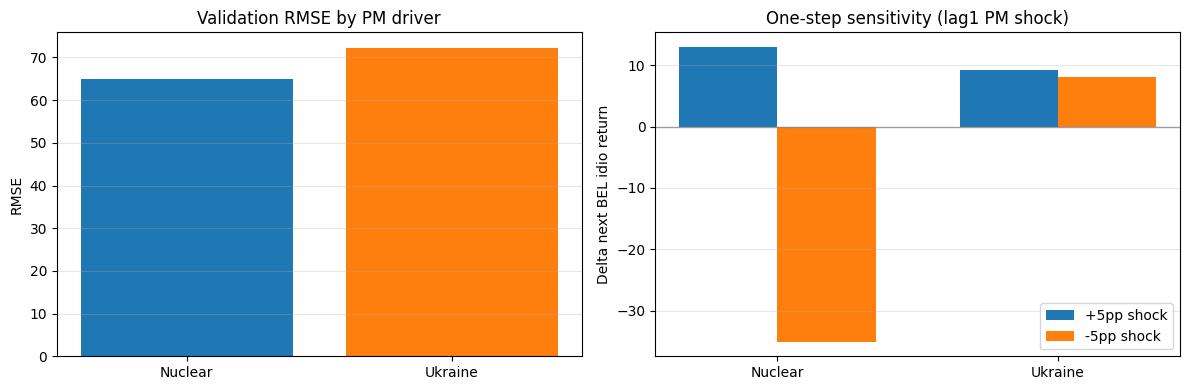

In [14]:
# ====================================================
# Separate PM-driver models: Ukraine-only vs Nuclear-only
# Compare best-fit performance and one-step PM shock sensitivity
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import ParameterGrid

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required. Run alignment/factor cells first.")

required_cols = ["timestamp", "price_Yes_nuclear", "price_Yes_ukraine", "BEL_idiosyncratic"]
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

# Build daily 2025 modeling frame (same convention as the main modeling cell)
ts_raw = hourly_aligned[required_cols].copy()
ts_raw["timestamp"] = pd.to_datetime(ts_raw["timestamp"], utc=True, errors="coerce")
ts_raw = ts_raw.dropna(subset=["timestamp"]).sort_values("timestamp")
ts_raw = ts_raw[ts_raw["timestamp"].dt.year == 2025].copy()
if ts_raw.empty:
    raise ValueError("No 2025 observations found for separate PM-driver comparison.")

ts_raw["date"] = ts_raw["timestamp"].dt.floor("D")
ts_daily = (
    ts_raw.groupby("date", as_index=False)
    .agg(
        {
            "price_Yes_nuclear": "last",
            "price_Yes_ukraine": "last",
            "BEL_idiosyncratic": "mean",
        }
    )
    .rename(columns={"date": "timestamp"})
)
ts_daily["PM_nuclear_returns"] = ts_daily["price_Yes_nuclear"].pct_change() * 100
ts_daily["PM_ukraine_returns"] = ts_daily["price_Yes_ukraine"].pct_change() * 100

def _rmse(a, p):
    a = np.asarray(a, dtype=float)
    p = np.asarray(p, dtype=float)
    return float(np.sqrt(np.mean((a - p) ** 2)))

def _mae(a, p):
    a = np.asarray(a, dtype=float)
    p = np.asarray(p, dtype=float)
    return float(np.mean(np.abs(a - p)))

def _rolling_from_params(coefs, intercept, train_df, val_df):
    k_ar = int(coefs.shape[0])
    hist = train_df.to_numpy(dtype=float).tolist()
    preds = []
    for i in range(len(val_df)):
        yhat = np.array(intercept, dtype=float).copy()
        for lag in range(1, k_ar + 1):
            yhat += coefs[lag - 1] @ np.array(hist[-lag], dtype=float)
        preds.append(yhat)
        hist.append(val_df.iloc[i].to_numpy(dtype=float))
    return pd.DataFrame(preds, columns=train_df.columns, index=val_df.index)

def _build_lagged_xy(df, x_col, y_col, n_lags):
    out = pd.DataFrame(index=df.index)
    for lag in range(1, n_lags + 1):
        out[f"{x_col}_lag{lag}"] = df[x_col].shift(lag)
        out[f"{y_col}_lag{lag}"] = df[y_col].shift(lag)
    out[y_col] = df[y_col]
    out = out.dropna()
    X = out.drop(columns=[y_col])
    y = out[y_col]
    return X, y

def _make_ml_est(model_name, params):
    if model_name == "Ridge":
        return Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=params["alpha"]))])
    if model_name == "SVR":
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", SVR(C=params["C"], epsilon=params["epsilon"], gamma=params["gamma"], kernel=params["kernel"])),
            ]
        )
    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )
    if model_name == "GradientBoosting":
        return GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42,
        )
    raise ValueError(f"Unsupported ML model: {model_name}")

market_specs = [
    ("PM_ukraine_returns", "Ukraine"),
    ("PM_nuclear_returns", "Nuclear"),
]

ml_space = {
    "Ridge": {"alpha": [0.1, 1.0, 10.0]},
    "SVR": {"C": [1.0, 5.0], "epsilon": [0.1, 0.2], "gamma": ["scale"], "kernel": ["linear", "rbf"]},
    "RandomForest": {"n_estimators": [200], "max_depth": [3, 5, None], "min_samples_leaf": [1, 2]},
    "GradientBoosting": {"n_estimators": [150, 300], "learning_rate": [0.03, 0.1], "max_depth": [2, 3]},
}

perf_rows = []
sens_rows = []
model_artifacts_by_market = {}

for x_col, market_label in market_specs:
    ts_mkt = ts_daily[["timestamp", x_col, "BEL_idiosyncratic"]].dropna().reset_index(drop=True)
    if len(ts_mkt) < 80:
        raise ValueError(f"Not enough rows for {market_label} model comparison: {len(ts_mkt)}")

    split_idx = len(ts_mkt) - 10
    train = ts_mkt.iloc[:split_idx][[x_col, "BEL_idiosyncratic"]].copy()
    val = ts_mkt.iloc[split_idx:][[x_col, "BEL_idiosyncratic"]].copy()

    candidates = []

    # Traditional: VAR + SVAR
    max_lag = min(8, max(2, len(train) // 10))
    for p in range(1, max_lag + 1):
        try:
            fit_var = VAR(train).fit(p)
            pred_var = _rolling_from_params(fit_var.coefs, fit_var.intercept, train, val)
            y_true = val["BEL_idiosyncratic"].to_numpy(dtype=float)
            y_pred = pred_var["BEL_idiosyncratic"].to_numpy(dtype=float)
            candidates.append(
                {
                    "market": market_label,
                    "driver": x_col,
                    "family": "Traditional",
                    "model": "VAR",
                    "spec": {"lag": int(fit_var.k_ar)},
                    "rmse": _rmse(y_true, y_pred),
                    "mae": _mae(y_true, y_pred),
                }
            )
        except Exception:
            pass

        try:
            A_template = np.array([[1, 0], ["E", 1]], dtype=object)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=FutureWarning)
                mod = SVAR(train, svar_type="A", A=A_template)
                fit_svar = mod.fit(maxlags=p, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
            if int(fit_svar.k_ar) >= 1:
                pred_svar = _rolling_from_params(fit_svar.coefs, fit_svar.intercept, train, val)
                y_true = val["BEL_idiosyncratic"].to_numpy(dtype=float)
                y_pred = pred_svar["BEL_idiosyncratic"].to_numpy(dtype=float)
                candidates.append(
                    {
                        "market": market_label,
                        "driver": x_col,
                        "family": "Traditional",
                        "model": "SVAR",
                        "spec": {"lag": int(fit_svar.k_ar)},
                        "rmse": _rmse(y_true, y_pred),
                        "mae": _mae(y_true, y_pred),
                    }
                )
        except Exception:
            pass

    # ML
    for n_lags in [1, 2, 3, 5]:
        X_all, y_all = _build_lagged_xy(ts_mkt[[x_col, "BEL_idiosyncratic"]], x_col, "BEL_idiosyncratic", n_lags)
        if len(X_all) < 40:
            continue
        split_ml = len(X_all) - 10
        if split_ml < 30:
            continue

        X_train, X_val = X_all.iloc[:split_ml], X_all.iloc[split_ml:]
        y_train, y_val = y_all.iloc[:split_ml], y_all.iloc[split_ml:]

        for model_name, param_space in ml_space.items():
            for params in ParameterGrid(param_space):
                try:
                    est = _make_ml_est(model_name, params)
                    est.fit(X_train, y_train)
                    pred = est.predict(X_val)
                    candidates.append(
                        {
                            "market": market_label,
                            "driver": x_col,
                            "family": "ML",
                            "model": model_name,
                            "spec": {"n_lags": int(n_lags), "params": dict(params)},
                            "rmse": _rmse(y_val.to_numpy(dtype=float), pred),
                            "mae": _mae(y_val.to_numpy(dtype=float), pred),
                        }
                    )
                except Exception:
                    pass

    if not candidates:
        raise RuntimeError(f"All candidates failed for {market_label} driver.")

    cand_df = pd.DataFrame(candidates).sort_values(["rmse", "mae"]).reset_index(drop=True)
    best = cand_df.iloc[0].to_dict()
    perf_rows.append(best)
    model_artifacts_by_market[market_label] = {"best": best, "all": cand_df}

    # -------------------------------
    # Sensitivity of the best model
    # -------------------------------
    x_hist = train[x_col].astype(float).tolist()
    y_hist = train["BEL_idiosyncratic"].astype(float).tolist()

    if best["family"] == "Traditional":
        lag = int(best["spec"].get("lag", 1))
        if best["model"] == "SVAR":
            A_template = np.array([[1, 0], ["E", 1]], dtype=object)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=FutureWarning)
                fit_best = SVAR(train, svar_type="A", A=A_template).fit(maxlags=lag, ic=None, trend="c", solver="nm", maxiter=2000, maxfun=4000)
            coefs = np.array(fit_best.coefs, dtype=float)
            intercept = np.array(fit_best.intercept, dtype=float)
        else:
            fit_best = VAR(train).fit(lag)
            coefs = np.array(fit_best.coefs, dtype=float)
            intercept = np.array(fit_best.intercept, dtype=float)

        k_ar = int(coefs.shape[0])

        def _one_step_linear(xh, yh):
            y_next = float(intercept[1])
            for l in range(1, k_ar + 1):
                A = coefs[l - 1]
                y_next += float(A[1, 0]) * float(xh[-l])
                y_next += float(A[1, 1]) * float(yh[-l])
            return float(y_next)

        base = _one_step_linear(x_hist, y_hist)
        x_plus = list(x_hist)
        x_minus = list(x_hist)
        x_plus[-1] += 5.0
        x_minus[-1] -= 5.0
        plus_delta = _one_step_linear(x_plus, y_hist) - base
        minus_delta = _one_step_linear(x_minus, y_hist) - base
        local_dydx = float(coefs[0, 1, 0])

    else:
        n_lags = int(best["spec"].get("n_lags", 2))
        params = dict(best["spec"].get("params", {}))
        X_all, y_all = _build_lagged_xy(ts_mkt[[x_col, "BEL_idiosyncratic"]], x_col, "BEL_idiosyncratic", n_lags)
        split_ml = len(X_all) - 10
        X_train = X_all.iloc[:split_ml].copy()
        y_train = y_all.iloc[:split_ml].copy()

        est = _make_ml_est(best["model"], params)
        est.fit(X_train, y_train)
        base_row = X_train.iloc[[-1]].copy()
        x_lag1_col = f"{x_col}_lag1"
        if x_lag1_col not in base_row.columns:
            raise RuntimeError(f"Missing expected feature column: {x_lag1_col}")

        base = float(est.predict(base_row)[0])

        row_p = base_row.copy()
        row_m = base_row.copy()
        row_p.loc[:, x_lag1_col] = float(row_p.iloc[0][x_lag1_col] + 1.0)
        row_m.loc[:, x_lag1_col] = float(row_m.iloc[0][x_lag1_col] - 1.0)
        local_dydx = float((est.predict(row_p)[0] - est.predict(row_m)[0]) / 2.0)

        row_p5 = base_row.copy()
        row_m5 = base_row.copy()
        row_p5.loc[:, x_lag1_col] = float(row_p5.iloc[0][x_lag1_col] + 5.0)
        row_m5.loc[:, x_lag1_col] = float(row_m5.iloc[0][x_lag1_col] - 5.0)
        plus_delta = float(est.predict(row_p5)[0] - base)
        minus_delta = float(est.predict(row_m5)[0] - base)

    sens_rows.append(
        {
            "market": market_label,
            "driver": x_col,
            "best_model": best["model"],
            "best_family": best["family"],
            "rmse": float(best["rmse"]),
            "mae": float(best["mae"]),
            "local_dy_dx_lag1": float(local_dydx),
            "delta_y_if_xlag1_plus5pp": float(plus_delta),
            "delta_y_if_xlag1_minus5pp": float(minus_delta),
        }
    )

separate_pm_performance = pd.DataFrame(perf_rows)
separate_pm_sensitivity = pd.DataFrame(sens_rows).sort_values("rmse").reset_index(drop=True)

print("Best model by market (Ukraine-only vs Nuclear-only):")
display(separate_pm_performance[["market", "driver", "family", "model", "rmse", "mae", "spec"]])

print("Sensitivity comparison of each market's best model:")
display(separate_pm_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(separate_pm_sensitivity["market"], separate_pm_sensitivity["rmse"], color=["tab:blue", "tab:orange"])
axes[0].set_title("Validation RMSE by PM driver")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

bar_w = 0.35
x = np.arange(len(separate_pm_sensitivity))
axes[1].bar(x - bar_w / 2, separate_pm_sensitivity["delta_y_if_xlag1_plus5pp"], width=bar_w, label="+5pp shock")
axes[1].bar(x + bar_w / 2, separate_pm_sensitivity["delta_y_if_xlag1_minus5pp"], width=bar_w, label="-5pp shock")
axes[1].set_xticks(x)
axes[1].set_xticklabels(separate_pm_sensitivity["market"].tolist())
axes[1].set_title("One-step sensitivity (lag1 PM shock)")
axes[1].set_ylabel("Delta next BEL idio return")
axes[1].axhline(0.0, color="gray", lw=1.0, alpha=0.7)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Backtest sample size: 363
Expanding window starts at train size: 50
Traditional settings used: VAR lag=1, SVAR lag=1


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.979e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.015e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(

Backtest model ranking (lower RMSE/MAE is better):


,model,family,n_forecasts,rmse,mae,directional_accuracy,pred_actual_corr
0,SVR,ML,313,598.807184,96.861330,0.677316,-0.029131
1,ExtraTrees,ML,313,610.273260,114.010621,0.603834,-0.003703
2,RandomForest,ML,313,613.289664,121.820096,0.594249,0.012158
3,GARCH,GARCH,313,614.804780,104.942441,0.607029,-0.084235
4,GradientBoosting,ML,313,671.109851,117.809683,0.648562,-0.008918
5,FoundationModel,Foundation,313,672.399539,115.232479,0.654952,-0.011932
6,VAR,Traditional,313,767.422610,129.361002,0.648562,-0.074825
7,SVAR,Traditional,313,767.422610,129.361002,0.648562,-0.074825
8,Ridge,ML,313,834.182745,166.267027,0.597444,-0.060402
9,Lasso,ML,313,834.183015,166.267935,0.597444,-0.060402


Best backtested model overall: SVR (ML)

Family summary:


,family,n_models,best_rmse,median_rmse,best_mae,median_mae,best_directional_accuracy
0,ML,7,598.807184,671.109851,96.861330,121.820096,0.677316
1,GARCH,1,614.804780,614.804780,104.942441,104.942441,0.607029
2,Foundation,1,672.399539,672.399539,115.232479,115.232479,0.654952
3,Traditional,2,767.422610,767.422610,129.361002,129.361002,0.648562


Selected for simulation/branching: SVR (ML)


,Model,Family,Validation RMSE
0,SVR,ML,598.807184
1,ExtraTrees,ML,610.273260
2,RandomForest,ML,613.289664
3,GARCH,GARCH,614.804780
4,GradientBoosting,ML,671.109851
5,FoundationModel,Foundation,672.399539
6,VAR,Traditional,767.422610
7,SVAR,Traditional,767.422610
8,Ridge,ML,834.182745
9,Lasso,ML,834.183015


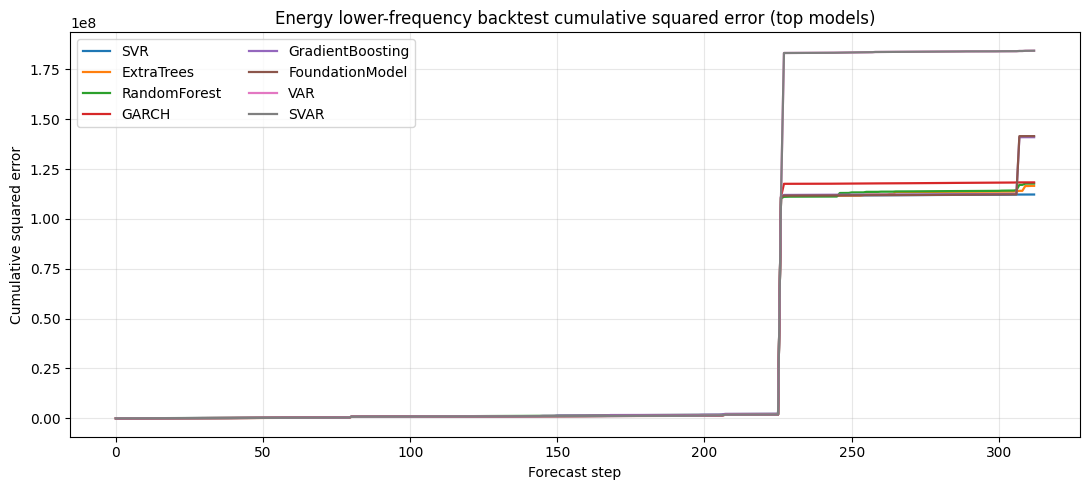

In [19]:
# ====================================================
# Expanding-window backtest across Traditional + ML + GARCH + Foundation
# Target: BEL_idiosyncratic
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.base import clone

try:
    from arch import arch_model
    HAS_ARCH = True
except Exception:
    HAS_ARCH = False

if "ts_df" not in globals() or not isinstance(ts_df, pd.DataFrame):
    raise ValueError("ts_df is required. Run the modeling stage cell first.")

required_bt_cols = ["PM_nuclear_returns", "PM_ukraine_returns", "BEL_idiosyncratic"]
missing_bt = [c for c in required_bt_cols if c not in ts_df.columns]
if missing_bt:
    raise ValueError(f"Backtest requires columns in ts_df: {missing_bt}")

bt_df = ts_df[required_bt_cols].dropna().copy().reset_index(drop=True)
if len(bt_df) < 80:
    raise ValueError(f"Need at least 80 observations for robust backtesting; got {len(bt_df)}")

n_lags_ml = 3
min_train = max(50, n_lags_ml + 20)
if len(bt_df) <= min_train + 10:
    raise ValueError(
        f"Not enough data for backtest with min_train={min_train}. Need > {min_train + 10}, got {len(bt_df)}."
    )

var_lag_bt = int(best_models.get("VAR", {}).get("lag", 1)) if isinstance(best_models.get("VAR"), dict) else 1
svar_lag_bt = int(best_models.get("SVAR", {}).get("lag", 1)) if isinstance(best_models.get("SVAR"), dict) else 1

print(f"Backtest sample size: {len(bt_df)}")
print(f"Expanding window starts at train size: {min_train}")
print(f"Traditional settings used: VAR lag={var_lag_bt}, SVAR lag={svar_lag_bt}")


def make_lagged_xy(df_slice, n_lags):
    rows = []
    for t in range(n_lags, len(df_slice)):
        rec = {"target": float(df_slice.iloc[t]["BEL_idiosyncratic"])}
        for lag in range(1, n_lags + 1):
            rec[f"nuclear_lag{lag}"] = float(df_slice.iloc[t - lag]["PM_nuclear_returns"])
            rec[f"ukraine_lag{lag}"] = float(df_slice.iloc[t - lag]["PM_ukraine_returns"])
            rec[f"idio_lag{lag}"] = float(df_slice.iloc[t - lag]["BEL_idiosyncratic"])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feature_cols = [c for c in out.columns if c != "target"]
    return out[feature_cols], out["target"], feature_cols


def make_next_features(df_slice, n_lags, feature_cols):
    rec = {}
    for lag in range(1, n_lags + 1):
        rec[f"nuclear_lag{lag}"] = float(df_slice.iloc[-lag]["PM_nuclear_returns"])
        rec[f"ukraine_lag{lag}"] = float(df_slice.iloc[-lag]["PM_ukraine_returns"])
        rec[f"idio_lag{lag}"] = float(df_slice.iloc[-lag]["BEL_idiosyncratic"])
    return pd.DataFrame([rec], columns=feature_cols)


def one_step_var(train_slice):
    try:
        fit = VAR(train_slice[["PM_nuclear_returns", "PM_ukraine_returns", "BEL_idiosyncratic"]]).fit(var_lag_bt)
        hist = train_slice[["PM_nuclear_returns", "PM_ukraine_returns", "BEL_idiosyncratic"]].to_numpy(dtype=float)[-fit.k_ar :]
        return float(fit.forecast(hist, steps=1)[0, 2])
    except Exception:
        return np.nan


def one_step_svar(train_slice):
    try:
        A_template = np.array(
            [
                [1, 0, 0],
                ["E", 1, 0],
                ["E", "E", 1],
            ],
            dtype=object,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(train_slice[["PM_nuclear_returns", "PM_ukraine_returns", "BEL_idiosyncratic"]], svar_type="A", A=A_template)
            fit = mod.fit(maxlags=svar_lag_bt, ic=None, trend="c", solver="nm", maxiter=3000, maxfun=6000)

        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        k_ar = int(coefs.shape[0])
        n_hist = train_slice["PM_nuclear_returns"].astype(float).tolist()
        u_hist = train_slice["PM_ukraine_returns"].astype(float).tolist()
        y_hist = train_slice["BEL_idiosyncratic"].astype(float).tolist()
        if len(y_hist) < k_ar:
            return np.nan

        y_next = float(intercept[2])
        for lag_i in range(1, k_ar + 1):
            A_lag = coefs[lag_i - 1]
            y_next += float(A_lag[2, 0]) * float(n_hist[-lag_i])
            y_next += float(A_lag[2, 1]) * float(u_hist[-lag_i])
            y_next += float(A_lag[2, 2]) * float(y_hist[-lag_i])
        return float(y_next)
    except Exception:
        return np.nan


def one_step_garch(train_slice):
    if not HAS_ARCH:
        return np.nan
    try:
        y_vals = train_slice["BEL_idiosyncratic"].astype(float).to_numpy()
        if len(y_vals) < 30:
            return np.nan
        model = arch_model(y_vals, vol="Garch", p=1, q=1, mean="AR", lags=1)
        fit = model.fit(disp="off")
        return float(fit.forecast(horizon=1).mean.iloc[-1, 0])
    except Exception:
        return np.nan


ml_model_space = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=20000, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))]),
    "FoundationModel": GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42),
}


def _rmse_np(y_true_arr, y_pred_arr):
    return float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2)))


def fit_predict_with_early_stopping(model_name, estimator, X_train, y_train, X_next):
    n = len(X_train)
    split = int(n * 0.8)
    if n < 35 or split < 20 or (n - split) < 8:
        estimator.fit(X_train, y_train)
        return float(estimator.predict(X_next)[0])

    X_tr = X_train.iloc[:split]
    y_tr = y_train.iloc[:split]
    X_va = X_train.iloc[split:]
    y_va = y_train.iloc[split:]

    if model_name in ["RandomForest", "ExtraTrees"]:
        n_grid = [50, 100, 200, 300, 500]
        best_rmse = np.inf
        best_n = n_grid[0]
        worse_streak = 0
        for n_est in n_grid:
            est_try = clone(estimator).set_params(n_estimators=n_est)
            est_try.fit(X_tr, y_tr)
            score = _rmse_np(y_va.to_numpy(dtype=float), est_try.predict(X_va))
            if score + 1e-9 < best_rmse:
                best_rmse = score
                best_n = n_est
                worse_streak = 0
            else:
                worse_streak += 1
                if worse_streak >= 1:
                    break
        final_est = clone(estimator).set_params(n_estimators=best_n)
        final_est.fit(X_train, y_train)
        return float(final_est.predict(X_next)[0])

    if model_name in ["GradientBoosting", "FoundationModel"]:
        est_try = clone(estimator)
        est_try.fit(X_tr, y_tr)
        if hasattr(est_try, "staged_predict"):
            best_iter = 1
            best_rmse = np.inf
            worse_streak = 0
            for i, pred_stage in enumerate(est_try.staged_predict(X_va), start=1):
                score = _rmse_np(y_va.to_numpy(dtype=float), pred_stage)
                if score + 1e-9 < best_rmse:
                    best_rmse = score
                    best_iter = i
                    worse_streak = 0
                else:
                    worse_streak += 1
                    if worse_streak >= 5:
                        break
            final_est = clone(estimator).set_params(n_estimators=max(10, best_iter))
            final_est.fit(X_train, y_train)
            return float(final_est.predict(X_next)[0])

    estimator.fit(X_train, y_train)
    return float(estimator.predict(X_next)[0])


rows = []
for t in range(min_train, len(bt_df)):
    train_slice = bt_df.iloc[:t].copy()
    y_true = float(bt_df.iloc[t]["BEL_idiosyncratic"])

    row = {"t": int(t), "y_true": y_true}
    row["VAR"] = one_step_var(train_slice)
    row["SVAR"] = one_step_svar(train_slice)
    row["GARCH"] = one_step_garch(train_slice)

    X_train, y_train, feat_cols = make_lagged_xy(train_slice, n_lags_ml)
    if len(X_train) < 25:
        for ml_name in ml_model_space.keys():
            row[ml_name] = np.nan
    else:
        X_next = make_next_features(train_slice, n_lags_ml, feat_cols)
        for ml_name, estimator in ml_model_space.items():
            try:
                row[ml_name] = fit_predict_with_early_stopping(
                    ml_name,
                    clone(estimator),
                    X_train,
                    y_train,
                    X_next,
                )
            except Exception:
                row[ml_name] = np.nan

    rows.append(row)

backtest_predictions_energy_lowerfreq = pd.DataFrame(rows)
model_cols_bt = [c for c in backtest_predictions_energy_lowerfreq.columns if c not in ["t", "y_true"]]

metric_rows = []
for m in model_cols_bt:
    tmp = backtest_predictions_energy_lowerfreq[["y_true", m]].dropna().copy()
    if len(tmp) == 0:
        continue
    err = tmp[m].to_numpy(dtype=float) - tmp["y_true"].to_numpy(dtype=float)
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    dir_acc = float(np.mean(np.sign(tmp[m].to_numpy()) == np.sign(tmp["y_true"].to_numpy())))
    corr = float(tmp[m].corr(tmp["y_true"])) if len(tmp) > 2 else np.nan
    family = "Traditional" if m in ["VAR", "SVAR"] else ("GARCH" if m == "GARCH" else ("Foundation" if m == "FoundationModel" else "ML"))
    metric_rows.append(
        {
            "model": m,
            "family": family,
            "n_forecasts": int(len(tmp)),
            "rmse": rmse,
            "mae": mae,
            "directional_accuracy": dir_acc,
            "pred_actual_corr": corr,
        }
    )

backtest_metrics_energy_lowerfreq = pd.DataFrame(metric_rows).sort_values(["rmse", "mae"]).reset_index(drop=True)

print("Backtest model ranking (lower RMSE/MAE is better):")
display(backtest_metrics_energy_lowerfreq)

if backtest_metrics_energy_lowerfreq.empty:
    raise RuntimeError("No valid model forecasts in backtest.")

best_overall = backtest_metrics_energy_lowerfreq.iloc[0]
best_model_name = str(best_overall["model"])
best_model_family = str(best_overall["family"])

family_summary = (
    backtest_metrics_energy_lowerfreq.groupby("family", as_index=False)
    .agg(
        n_models=("model", "count"),
        best_rmse=("rmse", "min"),
        median_rmse=("rmse", "median"),
        best_mae=("mae", "min"),
        median_mae=("mae", "median"),
        best_directional_accuracy=("directional_accuracy", "max"),
    )
    .sort_values("best_rmse")
    .reset_index(drop=True)
)

print(f"Best backtested model overall: {best_model_name} ({best_model_family})")
print("\nFamily summary:")
display(family_summary)

best_models["selected_model_for_simulation"] = best_model_name
best_models["selected_model_family"] = best_model_family
best_models["backtest_metrics_all_families"] = backtest_metrics_energy_lowerfreq.copy()

model_compare = backtest_metrics_energy_lowerfreq[["model", "family", "rmse"]].copy()
model_compare.columns = ["Model", "Family", "Validation RMSE"]
model_compare = model_compare.sort_values("Validation RMSE").reset_index(drop=True)

print(f"Selected for simulation/branching: {best_models['selected_model_for_simulation']} ({best_model_family})")
display(model_compare)

top_models = backtest_metrics_energy_lowerfreq.head(8)["model"].tolist()
if top_models:
    plt.figure(figsize=(11, 5))
    for m in top_models:
        tmp = backtest_predictions_energy_lowerfreq[["y_true", m]].dropna().copy()
        se = (tmp[m] - tmp["y_true"]) ** 2
        plt.plot(np.arange(len(se)), se.cumsum(), linewidth=1.6, label=m)
    plt.title("Energy lower-frequency backtest cumulative squared error (top models)")
    plt.xlabel("Forecast step")
    plt.ylabel("Cumulative squared error")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## Backtesting Traditional vs ML Predictive Models
This section runs an expanding-window, one-step-ahead backtest for BEL idiosyncratic return forecasts using identical train/test splits across models.
Traditional models (VAR/SVAR) are compared against ML models, then downstream branching/simulation is forced to the best backtested traditional model.

Simulation anchor timestamp (T-5): 2025-12-25 00:00:00+00:00
Electricity level at T-5: 65.111771
Forecast horizon: 5 observations

Market pipeline: PM_nuclear_returns


/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/seamusconlon/Desktop/KUL/Thesis/.venv/lib/python

Selected model for PM_nuclear_returns: SVR (ML)


,market,model,family,n_forecasts,rmse,mae,directional_accuracy
0,PM_nuclear_returns,SVR,ML,311,600.716329,97.515293,0.678457
1,PM_nuclear_returns,ExtraTrees,ML,311,607.458476,108.404290,0.617363
2,PM_nuclear_returns,GARCH,GARCH,311,616.766080,105.448190,0.604502
3,PM_nuclear_returns,RandomForest,ML,311,625.384244,123.663796,0.607717
4,PM_nuclear_returns,FoundationModel,Foundation,311,687.178161,123.874810,0.598071
5,PM_nuclear_returns,GradientBoosting,ML,311,701.186265,125.318816,0.617363
6,PM_nuclear_returns,VAR,Traditional,311,768.544386,127.370135,0.659164
7,PM_nuclear_returns,SVAR,Traditional,311,768.544386,127.370135,0.659164
8,PM_nuclear_returns,Ridge,ML,311,829.080038,159.074835,0.623794
9,PM_nuclear_returns,Lasso,ML,311,829.080531,159.075199,0.623794


Stage-1 calibration for PM_nuclear_returns: T-5=0.0040, down=0.0000, up=0.0090
Binomial path-level summary:


...

,market,selected_model,selected_family,best_rmse,best_mae
0,PM_ukraine_returns,ExtraTrees,ML,600.182854,103.272183
1,PM_nuclear_returns,SVR,ML,600.716329,97.515293



Joint terminal scenarios for hedge sizing:


,branch,market1,market1_resolution,market2,market2_resolution,probability,terminal_abnormal_return,max_drawdown,horizon_days,joint_probability_source
0,PM_nuclear_returns:0 | PM_ukraine_returns:0,PM_nuclear_returns,0,PM_ukraine_returns,0,0.986541,-0.526976,-0.626482,5,product_of_market_terminal_probs
1,PM_nuclear_returns:0 | PM_ukraine_returns:1,PM_nuclear_returns,0,PM_ukraine_returns,1,0.008960,-0.703937,-0.514037,5,product_of_market_terminal_probs
2,PM_nuclear_returns:1 | PM_ukraine_returns:0,PM_nuclear_returns,1,PM_ukraine_returns,0,0.004460,-0.526723,-0.626132,5,product_of_market_terminal_probs
3,PM_nuclear_returns:1 | PM_ukraine_returns:1,PM_nuclear_returns,1,PM_ukraine_returns,1,0.000041,-0.703683,-0.513688,5,product_of_market_terminal_probs


Total probability across joint scenarios: 1.000000
Joint distribution summary:


,metric,value
0,Expected terminal abnormal return,-0.528568
1,5% quantile (VaR-like),-0.703899
2,Expected shortfall 95%,-0.703937


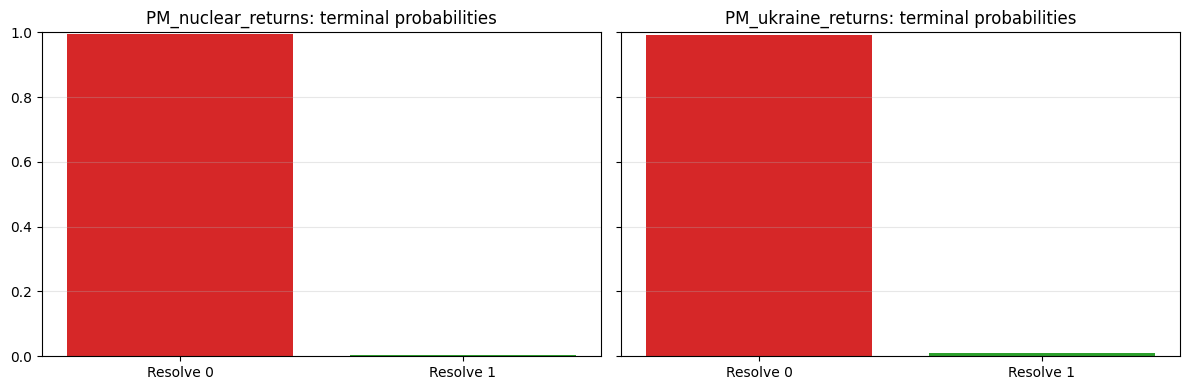

In [20]:
# ====================================================
# Separate market-specific modeling + Argentina-style branching
# Pipeline 1: PM_nuclear_returns -> BEL_idiosyncratic
# Pipeline 2: PM_ukraine_returns -> BEL_idiosyncratic
# ====================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.base import clone

try:
    from arch import arch_model
    HAS_ARCH = True
except Exception:
    HAS_ARCH = False

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned is required for simulation.")
if "best_models" not in globals() or not isinstance(best_models, dict):
    best_models = {}

y_idio_col = "BEL_idiosyncratic"
horizon = 5
n_lags_ml = 3

required_cols = [
    "timestamp",
    "price_Yes_nuclear",
    "price_Yes_ukraine",
    "Country Hourly - Belgium",
    y_idio_col,
]
missing = [c for c in required_cols if c not in hourly_aligned.columns]
if missing:
    raise ValueError(f"Missing required columns in hourly_aligned: {missing}")

sim_df_all = hourly_aligned[required_cols].copy().sort_values("timestamp").reset_index(drop=True)
sim_df_all["PM_nuclear_returns"] = sim_df_all["price_Yes_nuclear"].pct_change() * 100
sim_df_all["PM_ukraine_returns"] = sim_df_all["price_Yes_ukraine"].pct_change() * 100
sim_df_all = sim_df_all.dropna().copy()

if len(sim_df_all) < 80:
    raise ValueError(f"Need at least 80 aligned observations for robust market-specific modeling; got {len(sim_df_all)}")
if len(sim_df_all) <= horizon:
    raise ValueError("Not enough observations for a 5-step holdout simulation.")

t0_pos = len(sim_df_all) - (horizon + 1)
t0_row = sim_df_all.iloc[t0_pos]
t0_ts = pd.Timestamp(t0_row["timestamp"])
elec_t0 = float(t0_row["Country Hourly - Belgium"])

print(f"Simulation anchor timestamp (T-5): {t0_ts}")
print(f"Electricity level at T-5: {elec_t0:.6f}")
print(f"Forecast horizon: {horizon} observations")


market_cfg = {
    "PM_nuclear_returns": "price_Yes_nuclear",
    "PM_ukraine_returns": "price_Yes_ukraine",
}


def _rmse_np(y_true_arr, y_pred_arr):
    return float(np.sqrt(np.mean((y_true_arr - y_pred_arr) ** 2)))


def safe_return(next_level, prev_level):
    if prev_level <= 1e-12:
        return 0.0 if next_level <= 1e-12 else 1e6
    return float(next_level / prev_level - 1.0)


def build_lagged_xy(train_df, x_col, y_col, n_lags):
    rows = []
    for t in range(n_lags, len(train_df)):
        rec = {"target": float(train_df.iloc[t][y_col])}
        for lag in range(1, n_lags + 1):
            rec[f"{x_col}_lag{lag}"] = float(train_df.iloc[t - lag][x_col])
            rec[f"{y_col}_lag{lag}"] = float(train_df.iloc[t - lag][y_col])
        rows.append(rec)
    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(), pd.Series(dtype=float), []
    feat_cols = [c for c in out.columns if c != "target"]
    return out[feat_cols], out["target"], feat_cols


def one_step_var(train_slice, x_col, y_col, lag):
    try:
        fit = VAR(train_slice[[x_col, y_col]]).fit(max(1, int(lag)))
        hist = train_slice[[x_col, y_col]].to_numpy(dtype=float)[-fit.k_ar :]
        return float(fit.forecast(hist, steps=1)[0, 1])
    except Exception:
        return np.nan


def one_step_svar(train_slice, x_col, y_col, lag):
    try:
        A_template = np.array([[1, 0], ["E", 1]], dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            mod = SVAR(train_slice[[x_col, y_col]], svar_type="A", A=A_template)
            fit = mod.fit(maxlags=max(1, int(lag)), ic=None, trend="c", solver="nm", maxiter=3000, maxfun=6000)

        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        k_ar = int(coefs.shape[0])

        x_hist = train_slice[x_col].astype(float).tolist()
        y_hist = train_slice[y_col].astype(float).tolist()
        if len(y_hist) < k_ar:
            return np.nan

        y_next = float(intercept[1])
        for lag_i in range(1, k_ar + 1):
            A_lag = coefs[lag_i - 1]
            y_next += float(A_lag[1, 0]) * float(x_hist[-lag_i])
            y_next += float(A_lag[1, 1]) * float(y_hist[-lag_i])
        return float(y_next)
    except Exception:
        return np.nan


def one_step_garch(train_slice, y_col):
    if not HAS_ARCH:
        return np.nan
    try:
        y_vals = train_slice[y_col].astype(float).to_numpy()
        if len(y_vals) < 30:
            return np.nan
        model = arch_model(y_vals, vol="Garch", p=1, q=1, mean="AR", lags=1)
        fit = model.fit(disp="off")
        return float(fit.forecast(horizon=1).mean.iloc[-1, 0])
    except Exception:
        return np.nan


def ml_model_space():
    return {
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01, max_iter=20000, random_state=42),
        "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42),
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=400, min_samples_leaf=2, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "SVR": Pipeline([("scale", StandardScaler()), ("svr", SVR(C=1.0, epsilon=0.1, gamma="scale"))]),
        "FoundationModel": GradientBoostingRegressor(n_estimators=500, learning_rate=0.02, max_depth=2, random_state=42),
    }


def select_market_model(train_market, x_col, y_col):
    min_train = max(45, n_lags_ml + 20)
    var_lag_bt = int(best_models.get("VAR", {}).get("lag", 1)) if isinstance(best_models.get("VAR"), dict) else 1
    svar_lag_bt = int(best_models.get("SVAR", {}).get("lag", 1)) if isinstance(best_models.get("SVAR"), dict) else 1

    rows = []
    for t in range(min_train, len(train_market)):
        hist = train_market.iloc[:t].copy()
        y_true = float(train_market.iloc[t][y_col])
        row = {"t": int(t), "y_true": y_true}

        row["VAR"] = one_step_var(hist, x_col, y_col, var_lag_bt)
        row["SVAR"] = one_step_svar(hist, x_col, y_col, svar_lag_bt)
        row["GARCH"] = one_step_garch(hist, y_col)

        X_train, y_train, feat_cols = build_lagged_xy(hist, x_col, y_col, n_lags_ml)
        if len(X_train) < 25:
            for m in ml_model_space().keys():
                row[m] = np.nan
        else:
            x_next = {}
            for lag in range(1, n_lags_ml + 1):
                x_next[f"{x_col}_lag{lag}"] = float(hist.iloc[-lag][x_col])
                x_next[f"{y_col}_lag{lag}"] = float(hist.iloc[-lag][y_col])
            X_next = pd.DataFrame([x_next], columns=feat_cols)
            for m_name, est in ml_model_space().items():
                try:
                    model = clone(est)
                    model.fit(X_train, y_train)
                    row[m_name] = float(model.predict(X_next)[0])
                except Exception:
                    row[m_name] = np.nan

        rows.append(row)

    pred_df = pd.DataFrame(rows)
    model_cols = [c for c in pred_df.columns if c not in ["t", "y_true"]]

    metric_rows = []
    for m in model_cols:
        tmp = pred_df[["y_true", m]].dropna().copy()
        if tmp.empty:
            continue
        err = tmp[m].to_numpy(dtype=float) - tmp["y_true"].to_numpy(dtype=float)
        rmse = float(np.sqrt(np.mean(err ** 2)))
        mae = float(np.mean(np.abs(err)))
        direction = float(np.mean(np.sign(tmp[m].to_numpy()) == np.sign(tmp["y_true"].to_numpy())))
        fam = "Traditional" if m in ["VAR", "SVAR"] else ("GARCH" if m == "GARCH" else ("Foundation" if m == "FoundationModel" else "ML"))
        metric_rows.append(
            {
                "market": x_col,
                "model": m,
                "family": fam,
                "n_forecasts": int(len(tmp)),
                "rmse": rmse,
                "mae": mae,
                "directional_accuracy": direction,
            }
        )

    metrics = pd.DataFrame(metric_rows).sort_values(["rmse", "mae"]).reset_index(drop=True)
    if metrics.empty:
        raise RuntimeError(f"No valid backtest forecasts for market pipeline: {x_col}")

    best_row = metrics.iloc[0]
    return {
        "selected_model": str(best_row["model"]),
        "selected_family": str(best_row["family"]),
        "metrics": metrics,
        "pred_df": pred_df,
    }


def simulate_market_path(train_market, x_col, y_col, selected_model, x_future_path):
    y_hist = train_market[y_col].astype(float).tolist()
    x_hist = train_market[x_col].astype(float).tolist()

    if selected_model == "GARCH":
        if not HAS_ARCH:
            raise RuntimeError("arch package not available for GARCH simulation.")
        preds = []
        for _ in range(horizon):
            am = arch_model(np.array(y_hist, dtype=float), vol="Garch", p=1, q=1, mean="AR", lags=1)
            fit = am.fit(disp="off")
            y_next = float(fit.forecast(horizon=1).mean.iloc[-1, 0])
            preds.append(y_next)
            y_hist.append(y_next)
        return np.array(preds, dtype=float)

    if selected_model in ["VAR", "SVAR"]:
        if selected_model == "SVAR":
            lag = int(best_models.get("SVAR", {}).get("lag", 1)) if isinstance(best_models.get("SVAR"), dict) else 1
            A_template = np.array([[1, 0], ["E", 1]], dtype=object)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=FutureWarning)
                mod = SVAR(train_market[[x_col, y_col]], svar_type="A", A=A_template)
                fit = mod.fit(maxlags=max(1, lag), ic=None, trend="c", solver="nm", maxiter=3000, maxfun=6000)
        else:
            lag = int(best_models.get("VAR", {}).get("lag", 1)) if isinstance(best_models.get("VAR"), dict) else 1
            fit = VAR(train_market[[x_col, y_col]]).fit(max(1, lag))

        coefs = np.array(fit.coefs, dtype=float)
        intercept = np.array(fit.intercept, dtype=float)
        k_ar = int(coefs.shape[0])
        if len(y_hist) < k_ar or len(x_hist) < k_ar:
            raise RuntimeError(f"Insufficient history for k_ar={k_ar} in {selected_model} simulation.")

        preds = []
        for step in range(horizon):
            y_next = float(intercept[1])
            for lag_i in range(1, k_ar + 1):
                A_lag = coefs[lag_i - 1]
                y_next += float(A_lag[1, 0]) * float(x_hist[-lag_i])
                y_next += float(A_lag[1, 1]) * float(y_hist[-lag_i])
            preds.append(y_next)
            x_hist.append(float(x_future_path[step]))
            y_hist.append(y_next)
        return np.array(preds, dtype=float)

    X_train, y_train, feat_cols = build_lagged_xy(train_market, x_col, y_col, n_lags_ml)
    if len(X_train) < 25:
        raise RuntimeError(f"Insufficient lagged training rows for ML simulation in {x_col}.")

    model_space = ml_model_space()
    if selected_model not in model_space:
        selected_model = "GradientBoosting"
    model = clone(model_space[selected_model])
    model.fit(X_train, y_train)

    preds = []
    for step in range(horizon):
        row = {}
        for lag in range(1, n_lags_ml + 1):
            row[f"{x_col}_lag{lag}"] = float(x_hist[-lag])
            row[f"{y_col}_lag{lag}"] = float(y_hist[-lag])
        X_next = pd.DataFrame([row], columns=feat_cols)
        y_next = float(model.predict(X_next)[0])
        preds.append(y_next)
        x_hist.append(float(x_future_path[step]))
        y_hist.append(y_next)
    return np.array(preds, dtype=float)


model_pipeline_summary_rows = []
scenario_summary_by_market = {}
terminal_summary_by_market = {}
path_outputs_by_market = {}

for market_ret_col, market_level_col in market_cfg.items():
    print("\n" + "=" * 80)
    print(f"Market pipeline: {market_ret_col}")

    train_market = sim_df_all.iloc[: t0_pos + 1][[market_ret_col, y_idio_col]].copy()
    if len(train_market) < 55:
        raise ValueError(f"Training sample too short for {market_ret_col}: {len(train_market)}")

    model_pick = select_market_model(train_market, market_ret_col, y_idio_col)
    selected_model = model_pick["selected_model"]
    selected_family = model_pick["selected_family"]
    metrics = model_pick["metrics"].copy()

    print(f"Selected model for {market_ret_col}: {selected_model} ({selected_family})")
    display(metrics.head(10))

    model_pipeline_summary_rows.append(
        {
            "market": market_ret_col,
            "selected_model": selected_model,
            "selected_family": selected_family,
            "best_rmse": float(metrics.iloc[0]["rmse"]),
            "best_mae": float(metrics.iloc[0]["mae"]),
        }
    )

    p_t0 = float(np.clip(t0_row[market_level_col], 0.0, 1.0))
    pm_hist = sim_df_all.iloc[: t0_pos + 1][market_level_col].astype(float).clip(0.0, 1.0)
    delta_hist = pm_hist.diff().dropna()
    if delta_hist.empty:
        raise RuntimeError(f"Insufficient level history for {market_level_col} to calibrate Stage-1 nodes.")

    q_down = float(delta_hist.quantile(0.25))
    q_up = float(delta_hist.quantile(0.75))
    if abs(q_up - q_down) < 1e-10:
        std_val = float(delta_hist.std(ddof=0)) if float(delta_hist.std(ddof=0)) > 0 else 1e-3
        eps = max(1e-4, std_val)
        q_down, q_up = -eps, eps

    p_stage1_down = float(np.clip(p_t0 + q_down, 0.0, 1.0))
    p_stage1_up = float(np.clip(p_t0 + q_up, 0.0, 1.0))
    if abs(p_stage1_up - p_stage1_down) < 1e-10:
        med_abs = float(delta_hist.abs().median()) if not delta_hist.empty else 1e-3
        bump = min(0.05, max(1e-3, med_abs))
        p_stage1_down = float(np.clip(p_t0 - bump, 0.0, 1.0))
        p_stage1_up = float(np.clip(p_t0 + bump, 0.0, 1.0))

    stage1_nodes = {"down": p_stage1_down, "up": p_stage1_up}
    stage1_prob = {"down": 0.5, "up": 0.5}

    print(f"Stage-1 calibration for {market_ret_col}: T-5={p_t0:.4f}, down={p_stage1_down:.4f}, up={p_stage1_up:.4f}")

    scenario_rows = []
    path_outputs = {}

    for s1_name, p1 in stage1_nodes.items():
        p1_prob = float(stage1_prob[s1_name])
        ret_step1 = safe_return(p1, p_t0) * 100.0

        for terminal in [1.0, 0.0]:
            ret_terminal = safe_return(terminal, p1) * 100.0
            x_future_path = np.zeros(horizon, dtype=float)
            x_future_path[0] = ret_step1
            x_future_path[-1] = ret_terminal

            idio_path = simulate_market_path(train_market, market_ret_col, y_idio_col, selected_model, x_future_path)
            elec_path = elec_t0 * np.cumprod(1.0 + idio_path / 100.0)

            cond_prob = float(np.clip(p1, 0.0, 1.0)) if terminal == 1.0 else float(1.0 - np.clip(p1, 0.0, 1.0))
            joint_prob = p1_prob * cond_prob
            node_name = f"{s1_name}->resolve_{int(terminal)}"

            path_outputs[node_name] = {
                "elec_path": elec_path,
                "idio_path": idio_path,
                "x_future_path": x_future_path,
                "joint_prob": joint_prob,
                "terminal": int(terminal),
            }

            scenario_rows.append(
                {
                    "market": market_ret_col,
                    "selected_model": selected_model,
                    "selected_family": selected_family,
                    "branch": node_name,
                    "stage1": s1_name,
                    "stage1_prob_node": p1,
                    "probability": joint_prob,
                    "terminal_resolution": int(terminal),
                    "base_prob_t_minus_5": p_t0,
                    "step1_prob_level": p1,
                    "horizon_days": horizon,
                    "terminal_abnormal_return": float(elec_path[-1] / elec_t0 - 1.0),
                    "max_drawdown": float((elec_path / np.maximum.accumulate(elec_path) - 1.0).min()),
                }
            )

    scenario_summary = pd.DataFrame(scenario_rows).sort_values(["stage1", "terminal_resolution"]).reset_index(drop=True)
    print("Binomial path-level summary:")
    display(scenario_summary)

    terminal_summary = (
        scenario_summary.groupby("terminal_resolution", as_index=False)
        .apply(
            lambda g: pd.Series(
                {
                    "total_probability": g["probability"].sum(),
                    "expected_terminal_abnormal_return": np.average(g["terminal_abnormal_return"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
                    "weighted_max_drawdown": np.average(g["max_drawdown"], weights=g["probability"]) if g["probability"].sum() > 0 else np.nan,
                }
            )
        )
        .reset_index(drop=True)
    )
    terminal_summary["terminal_label"] = terminal_summary["terminal_resolution"].map({1: "Resolves to 1", 0: "Resolves to 0"})
    terminal_summary = terminal_summary[
        [
            "terminal_resolution",
            "terminal_label",
            "total_probability",
            "expected_terminal_abnormal_return",
            "weighted_max_drawdown",
        ]
    ]

    print("Terminal-node summary (only two final nodes):")
    display(terminal_summary)
    print(f"Total probability across all branches: {float(scenario_summary['probability'].sum()):.6f}")

    scenario_summary_by_market[market_ret_col] = scenario_summary
    terminal_summary_by_market[market_ret_col] = terminal_summary
    path_outputs_by_market[market_ret_col] = path_outputs


model_pipeline_summary = pd.DataFrame(model_pipeline_summary_rows).sort_values("best_rmse").reset_index(drop=True)
print("\nMarket-specific model pipeline summary:")
display(model_pipeline_summary)


mkt_keys = list(terminal_summary_by_market.keys())
if len(mkt_keys) != 2:
    raise ValueError("Joint scenario construction expects exactly two PM markets.")

m1, m2 = mkt_keys[0], mkt_keys[1]
t1 = terminal_summary_by_market[m1].copy()
t2 = terminal_summary_by_market[m2].copy()

joint_rows = []
for _, r1 in t1.iterrows():
    for _, r2 in t2.iterrows():
        p_joint = float(r1["total_probability"] * r2["total_probability"])
        ret_joint = float(0.5 * r1["expected_terminal_abnormal_return"] + 0.5 * r2["expected_terminal_abnormal_return"])
        mdd_joint = float(0.5 * r1["weighted_max_drawdown"] + 0.5 * r2["weighted_max_drawdown"])

        joint_rows.append(
            {
                "branch": f"{m1}:{int(r1['terminal_resolution'])} | {m2}:{int(r2['terminal_resolution'])}",
                "market1": m1,
                "market1_resolution": int(r1["terminal_resolution"]),
                "market2": m2,
                "market2_resolution": int(r2["terminal_resolution"]),
                "probability": p_joint,
                "terminal_abnormal_return": ret_joint,
                "max_drawdown": mdd_joint,
                "horizon_days": horizon,
                "joint_probability_source": "product_of_market_terminal_probs",
            }
        )

joint_terminal_scenarios = pd.DataFrame(joint_rows).sort_values(["market1_resolution", "market2_resolution"]).reset_index(drop=True)
print("\nJoint terminal scenarios for hedge sizing:")
display(joint_terminal_scenarios)
print(f"Total probability across joint scenarios: {float(joint_terminal_scenarios['probability'].sum()):.6f}")

scenario_stats = pd.DataFrame(
    {
        "metric": ["Expected terminal abnormal return", "5% quantile (VaR-like)", "Expected shortfall 95%"],
        "value": [
            float((joint_terminal_scenarios["probability"] * joint_terminal_scenarios["terminal_abnormal_return"]).sum()),
            float(joint_terminal_scenarios["terminal_abnormal_return"].quantile(0.05)),
            float(
                joint_terminal_scenarios.loc[
                    joint_terminal_scenarios["terminal_abnormal_return"] <= joint_terminal_scenarios["terminal_abnormal_return"].quantile(0.05),
                    "terminal_abnormal_return",
                ].mean()
            ),
        ],
    }
)
print("Joint distribution summary:")
display(scenario_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, mk in zip(axes, mkt_keys):
    ts = terminal_summary_by_market[mk].sort_values("terminal_resolution")
    labels = [f"Resolve {int(x)}" for x in ts["terminal_resolution"]]
    ax.bar(labels, ts["total_probability"], color=["tab:red", "tab:green"])
    ax.set_title(f"{mk}: terminal probabilities")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

scenario_summary = joint_terminal_scenarios.copy()
binomial_scenario_summary = scenario_summary_by_market
binomial_terminal_summary = terminal_summary_by_market
binomial_stats = scenario_stats
best_models["market_specific_pipeline_summary"] = model_pipeline_summary.copy()

## Empirical Branching Trees by Market
Visualize the branching simulation structure separately for Nuclear and Ukraine in a stage-based tree layout (Now -> Stage 1 -> Terminal nodes), with branch probabilities and modeled terminal impacts.

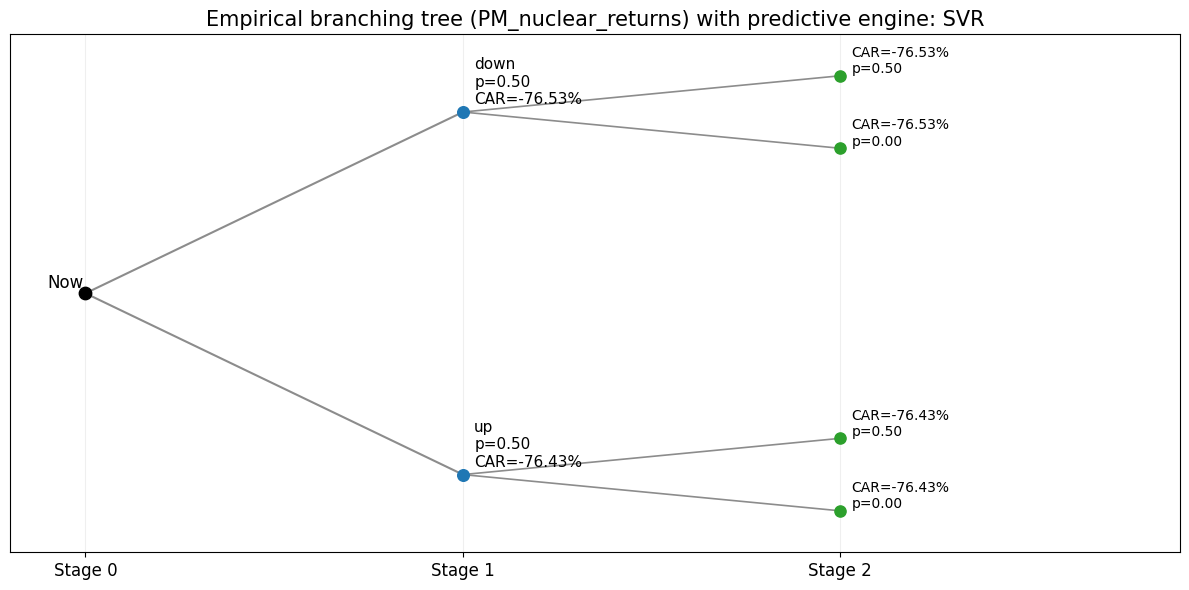

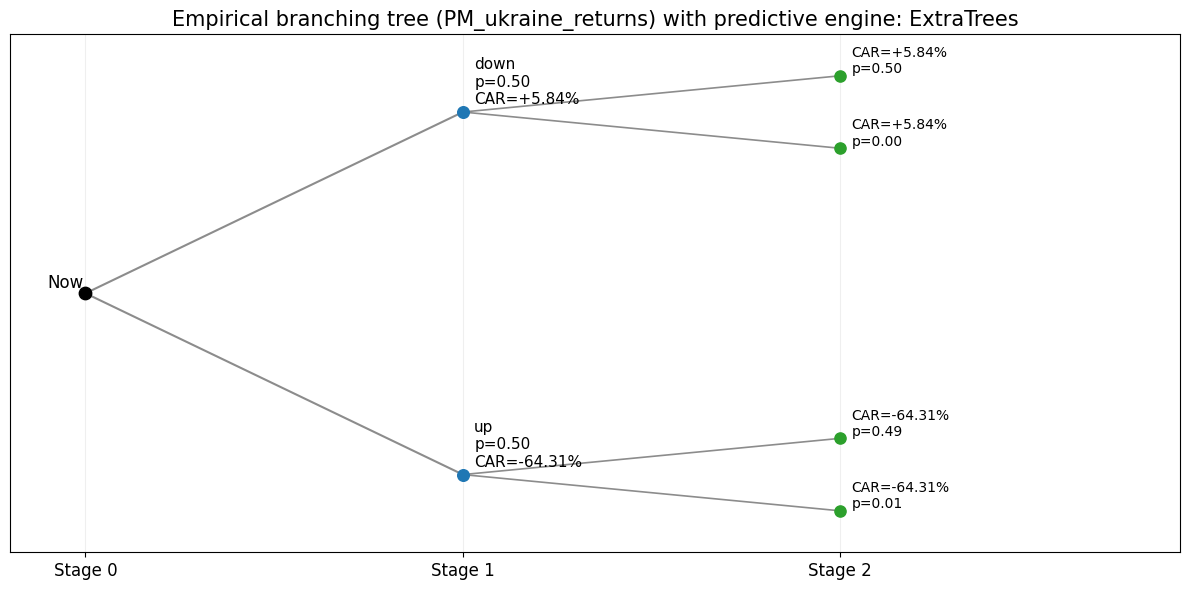

In [30]:
# Stage-based branching-tree visualization for each market (Argentina-style)
import numpy as np
import matplotlib.pyplot as plt

if "scenario_summary_by_market" not in globals() or not isinstance(scenario_summary_by_market, dict) or not scenario_summary_by_market:
    raise ValueError("scenario_summary_by_market is required. Run the market-specific branching simulation cell first.")
if "model_pipeline_summary" not in globals():
    model_pipeline_summary = None


def _fmt_pct(x):
    return f"{100.0 * float(x):+.2f}%"


for market_key, s_df in scenario_summary_by_market.items():
    if s_df is None or s_df.empty:
        continue

    work = s_df.copy()
    work = work.sort_values(["stage1", "terminal_resolution"]).reset_index(drop=True)

    stage1_stats = (
        work.groupby("stage1", as_index=False)
        .apply(
            lambda g: pd.Series(
                {
                    "stage1_prob": float(g["probability"].sum()),
                    "stage1_expected_car": float(np.average(g["terminal_abnormal_return"], weights=g["probability"])) if float(g["probability"].sum()) > 0 else np.nan,
                    "stage1_prob_level": float(g["stage1_prob_node"].iloc[0]) if "stage1_prob_node" in g.columns else np.nan,
                }
            )
        )
        .reset_index(drop=True)
    )

    stage1_order = stage1_stats["stage1"].tolist()
    n1 = len(stage1_order)

    x0, x1, x2 = 0.0, 1.0, 2.0
    y0 = 0.0
    y1_vals = np.linspace(0.7, -0.7, n1) if n1 > 1 else np.array([0.0])
    y1_map = {name: float(y) for name, y in zip(stage1_order, y1_vals)}

    leaf_rows = []
    for stg in stage1_order:
        sub = work[work["stage1"] == stg].sort_values("terminal_resolution").reset_index(drop=True)
        m = len(sub)
        if m == 1:
            y_leaf = [y1_map[stg]]
        else:
            spread = 0.28
            y_leaf = np.linspace(y1_map[stg] + spread / 2, y1_map[stg] - spread / 2, m)
        for i in range(m):
            rec = sub.iloc[i].to_dict()
            rec["y_leaf"] = float(y_leaf[i])
            leaf_rows.append(rec)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter([x0], [y0], color="black", s=80, zorder=3)
    ax.text(x0 - 0.1, y0 + 0.02, "Now", fontsize=12)

    for _, r in stage1_stats.iterrows():
        stg = r["stage1"]
        y1 = y1_map[stg]

        ax.plot([x0, x1], [y0, y1], color="gray", linewidth=1.5, alpha=0.9)
        ax.scatter([x1], [y1], color="#1f77b4", s=70, zorder=3)

        stage_label = (
            f"{stg}\n"
            f"p={float(r['stage1_prob']):.2f}\n"
            f"CAR={_fmt_pct(r['stage1_expected_car'])}"
        )
        ax.text(x1 + 0.03, y1 + 0.03, stage_label, fontsize=11)

    for leaf in leaf_rows:
        stg = str(leaf["stage1"])
        y1 = y1_map[stg]
        y2 = float(leaf["y_leaf"])

        ax.plot([x1, x2], [y1, y2], color="gray", linewidth=1.2, alpha=0.9)
        ax.scatter([x2], [y2], color="#2ca02c", s=65, zorder=3)

        leaf_label = (
            f"CAR={_fmt_pct(leaf['terminal_abnormal_return'])}\n"
            f"p={float(leaf['probability']):.2f}"
        )
        ax.text(x2 + 0.03, y2 + 0.01, leaf_label, fontsize=10)

    model_name = "n/a"
    if isinstance(model_pipeline_summary, pd.DataFrame) and not model_pipeline_summary.empty:
        msel = model_pipeline_summary.loc[model_pipeline_summary["market"] == market_key]
        if not msel.empty:
            model_name = str(msel.iloc[0]["selected_model"])

    ax.set_title(f"Empirical branching tree ({market_key}) with predictive engine: {model_name}", fontsize=15)
    ax.set_xticks([x0, x1, x2])
    ax.set_xticklabels(["Stage 0", "Stage 1", "Stage 2"], fontsize=12)
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.2)
    ax.set_xlim(-0.2, 2.9)
    ax.set_ylim(-1.0, 1.0)
    plt.tight_layout()
    plt.show()

One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):


,market,family,model,baseline_h1,delta_h1_if_plus5pp,delta_h1_if_minus5pp,local_dy_dx_approx
0,PM_nuclear_returns,ML,SVR,-27.364182,0.0,0.0,0.0
1,PM_ukraine_returns,ML,ExtraTrees,-44.928827,0.0,0.0,0.0


Sensitivity grid summary (terminal and cumulative impact):


,market,family,model,horizon_days,shock_pp,impact_h1,impact_terminal,impact_cumulative
0,PM_nuclear_returns,ML,SVR,1,-15.0,0.0,0.000000,0.000000
1,PM_nuclear_returns,ML,SVR,2,-15.0,0.0,-0.810607,-0.810607
2,PM_nuclear_returns,ML,SVR,3,-15.0,0.0,0.460830,-0.349777
3,PM_nuclear_returns,ML,SVR,5,-15.0,0.0,-0.003452,-1.300049
4,PM_nuclear_returns,ML,SVR,1,-10.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...
59,PM_ukraine_returns,ML,ExtraTrees,5,10.0,0.0,-17.667177,-412.352480
60,PM_ukraine_returns,ML,ExtraTrees,1,15.0,0.0,0.000000,0.000000
61,PM_ukraine_returns,ML,ExtraTrees,2,15.0,0.0,-10.191141,-10.191141
62,PM_ukraine_returns,ML,ExtraTrees,3,15.0,0.0,-155.804226,-165.995366


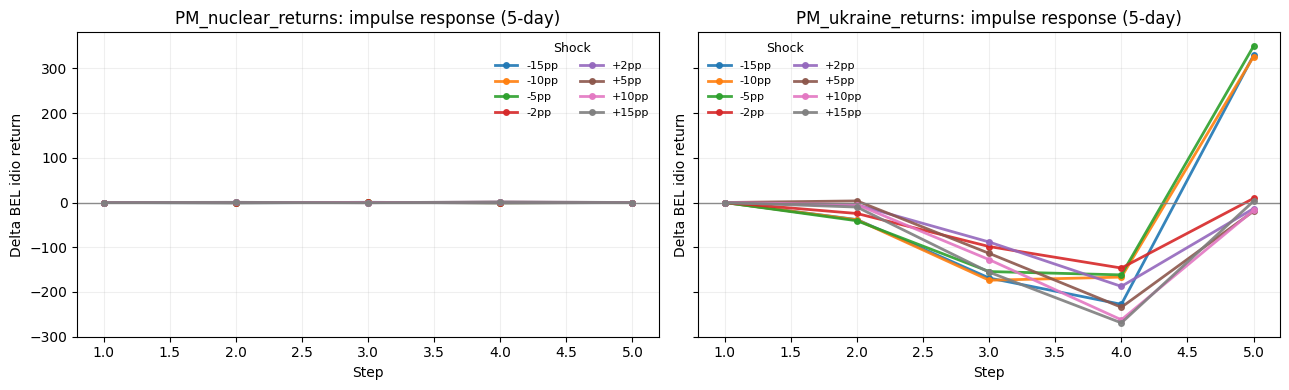

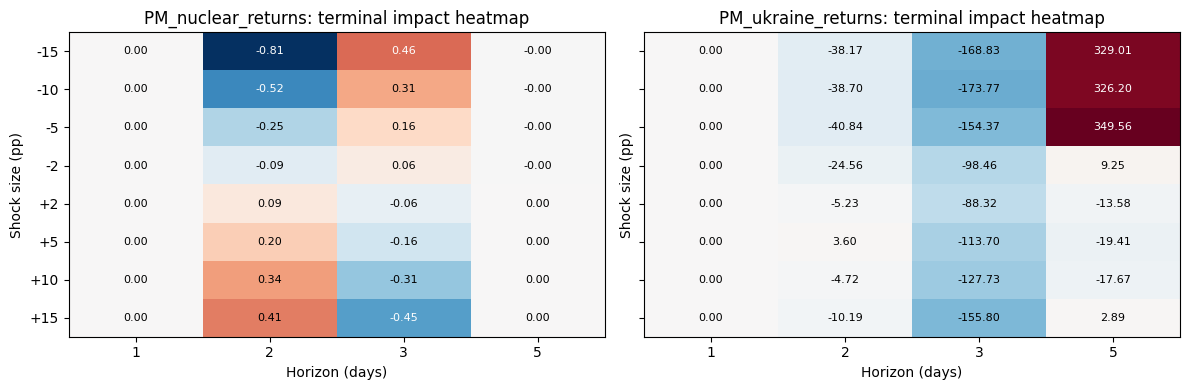

In [28]:
# ====================================================
# Impulse-response and shock sensitivity (Argentina-style)
# Uses market-specific selected models from the two-pipeline cell
# ====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

if "model_pipeline_summary" not in globals() or not isinstance(model_pipeline_summary, pd.DataFrame) or model_pipeline_summary.empty:
    raise ValueError("model_pipeline_summary is required. Run the separate market-specific branching cell first.")
if "sim_df_all" not in globals() or not isinstance(sim_df_all, pd.DataFrame) or sim_df_all.empty:
    raise ValueError("sim_df_all is required. Run the separate market-specific branching cell first.")
if "t0_pos" not in globals():
    raise ValueError("t0_pos not found. Run the separate market-specific branching cell first.")
if "simulate_market_path" not in globals():
    raise ValueError("simulate_market_path() not found. Run the separate market-specific branching cell first.")

y_idio_col = "BEL_idiosyncratic"
market_cols = ["PM_nuclear_returns", "PM_ukraine_returns"]
horizon_grid = [1, 2, 3, 5]
shock_pp_grid = [2, 5, 10, 15]
full_horizon = int(globals().get("horizon", 5))

rows = []
one_step_rows = []
irf_curve_rows = []

for mkt in market_cols:
    sel = model_pipeline_summary.loc[model_pipeline_summary["market"] == mkt]
    if sel.empty:
        raise ValueError(f"Selected model not found in model_pipeline_summary for {mkt}")

    selected_model = str(sel.iloc[0]["selected_model"])
    selected_family = str(sel.iloc[0]["selected_family"])
    train_market = sim_df_all.iloc[: t0_pos + 1][[mkt, y_idio_col]].copy()

    x_base_full = np.zeros(full_horizon, dtype=float)
    y_base_full = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_base_full)

    for horizon_days in horizon_grid:
        if horizon_days > full_horizon:
            raise ValueError(f"Requested horizon {horizon_days} exceeds full horizon {full_horizon}")

        y_base = y_base_full[:horizon_days]

        for shock_pp in shock_pp_grid:
            for shock_sign in [1.0, -1.0]:
                signed_shock = float(shock_sign * shock_pp)
                x_shock_full = np.zeros(full_horizon, dtype=float)
                x_shock_full[0] = signed_shock

                y_shock_full = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_shock_full)
                y_shock = y_shock_full[:horizon_days]
                irf_path = y_shock - y_base

                rows.append(
                    {
                        "market": mkt,
                        "family": selected_family,
                        "model": selected_model,
                        "horizon_days": int(horizon_days),
                        "shock_pp": float(signed_shock),
                        "impact_h1": float(irf_path[0]),
                        "impact_terminal": float(irf_path[-1]),
                        "impact_cumulative": float(np.sum(irf_path)),
                    }
                )

                for h in range(horizon_days):
                    irf_curve_rows.append(
                        {
                            "market": mkt,
                            "model": selected_model,
                            "family": selected_family,
                            "shock_pp": float(signed_shock),
                            "horizon_days": int(horizon_days),
                            "step": int(h + 1),
                            "irf_delta_idio_return": float(irf_path[h]),
                        }
                    )

    # One-step symmetric counterfactual around lag1 shock (+/-5pp)
    x0 = np.zeros(full_horizon, dtype=float)
    y0 = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x0)[0]
    x_p5 = np.zeros(full_horizon, dtype=float)
    x_p5[0] = 5.0
    x_m5 = np.zeros(full_horizon, dtype=float)
    x_m5[0] = -5.0
    y_p5 = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_p5)[0]
    y_m5 = simulate_market_path(train_market, mkt, y_idio_col, selected_model, x_m5)[0]

    one_step_rows.append(
        {
            "market": mkt,
            "family": selected_family,
            "model": selected_model,
            "baseline_h1": float(y0),
            "delta_h1_if_plus5pp": float(y_p5 - y0),
            "delta_h1_if_minus5pp": float(y_m5 - y0),
            "local_dy_dx_approx": float((y_p5 - y_m5) / 10.0),
        }
    )

sensitivity_irf_grid = pd.DataFrame(rows).sort_values(["market", "shock_pp", "horizon_days"]).reset_index(drop=True)
irf_curve_df = pd.DataFrame(irf_curve_rows).sort_values(["market", "shock_pp", "horizon_days", "step"]).reset_index(drop=True)
one_step_irf_sensitivity = pd.DataFrame(one_step_rows).sort_values("market").reset_index(drop=True)

print("One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):")
display(one_step_irf_sensitivity)

print("Sensitivity grid summary (terminal and cumulative impact):")
display(sensitivity_irf_grid)

# Plot impulse-response curves for 5-day horizon only
plot_df = irf_curve_df[irf_curve_df["horizon_days"] == 5].copy()
fig, axes = plt.subplots(1, len(market_cols), figsize=(13, 4), sharey=True)
if len(market_cols) == 1:
    axes = [axes]

for ax, mkt in zip(axes, market_cols):
    sub = plot_df[plot_df["market"] == mkt].copy()
    for shock in sorted(sub["shock_pp"].unique()):
        s = sub[sub["shock_pp"] == shock].sort_values("step")
        ax.plot(
            s["step"],
            s["irf_delta_idio_return"],
            marker="o",
            markersize=4,
            linewidth=2.0,
            alpha=0.9,
            label=f"{shock:+.0f}pp",
        )
    ax.axhline(0.0, color="gray", linewidth=1.0, alpha=0.9)
    ax.set_title(f"{mkt}: impulse response (5-day)", fontsize=12)
    ax.set_xlabel("Step")
    ax.set_ylabel("Delta BEL idio return")
    ax.grid(alpha=0.2)
    ax.legend(title="Shock", fontsize=8, title_fontsize=9, ncol=2, frameon=False, loc="best")

plt.tight_layout()
plt.show()

# Heatmaps for terminal impact by market (cleaned: no colorbar scale)
fig, axes = plt.subplots(1, len(market_cols), figsize=(12, 4), sharey=True)
if len(market_cols) == 1:
    axes = [axes]

for ax, mkt in zip(axes, market_cols):
    sub = sensitivity_irf_grid[sensitivity_irf_grid["market"] == mkt].copy()
    piv = sub.pivot(index="shock_pp", columns="horizon_days", values="impact_terminal").sort_index()

    vmax = float(np.nanmax(np.abs(piv.values))) if np.isfinite(piv.values).any() else 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    ax.imshow(piv.values, aspect="auto", cmap="RdBu_r", norm=norm)

    ax.set_title(f"{mkt}: terminal impact heatmap", fontsize=12)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("Shock size (pp)")
    ax.set_xticks(np.arange(len(piv.columns)))
    ax.set_xticklabels([str(c) for c in piv.columns])
    ax.set_yticks(np.arange(len(piv.index)))
    ax.set_yticklabels([f"{v:+.0f}" for v in piv.index])

    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            val = float(piv.values[i, j])
            txt_color = "white" if abs(val) > 0.55 * vmax else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)

plt.tight_layout()
plt.show()

## Nuclear Market Analysis
Argentina-style reporting for the Nuclear pipeline: path-level branches, terminal-node summary, one-step counterfactual sensitivity, and multi-horizon shock grid.

In [26]:
# Nuclear-only reporting block (Argentina-style summaries)
import pandas as pd

nuclear_key = "PM_nuclear_returns"
if "scenario_summary_by_market" not in globals() or nuclear_key not in scenario_summary_by_market:
    raise ValueError("Nuclear scenario summary missing. Run the market-specific branching cell first.")
if "terminal_summary_by_market" not in globals() or nuclear_key not in terminal_summary_by_market:
    raise ValueError("Nuclear terminal summary missing. Run the market-specific branching cell first.")
if "one_step_irf_sensitivity" not in globals() or not isinstance(one_step_irf_sensitivity, pd.DataFrame):
    raise ValueError("one_step_irf_sensitivity missing. Run the impulse-response cell first.")
if "sensitivity_irf_grid" not in globals() or not isinstance(sensitivity_irf_grid, pd.DataFrame):
    raise ValueError("sensitivity_irf_grid missing. Run the impulse-response cell first.")

nuclear_paths = scenario_summary_by_market[nuclear_key].copy()
nuclear_terminal = terminal_summary_by_market[nuclear_key].copy()
nuclear_one_step = one_step_irf_sensitivity[one_step_irf_sensitivity["market"] == nuclear_key].copy().reset_index(drop=True)
nuclear_grid = sensitivity_irf_grid[sensitivity_irf_grid["market"] == nuclear_key].copy().reset_index(drop=True)

print("Binomial path-level summary:")
display(nuclear_paths)

print("Terminal-node summary (only two final nodes):")
display(nuclear_terminal)

print("One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):")
display(nuclear_one_step)

print("Sensitivity grid summary (terminal and cumulative impact):")
display(nuclear_grid)

nuclear_prob_check = float(nuclear_paths["probability"].sum())
print(f"Total probability across all branches: {nuclear_prob_check:.6f}")

Binomial path-level summary:


,market,selected_model,selected_family,branch,stage1,stage1_prob_node,probability,terminal_resolution,base_prob_t_minus_5,step1_prob_level,horizon_days,terminal_abnormal_return,max_drawdown
0,PM_nuclear_returns,SVR,ML,down->resolve_0,down,0.000,0.5000,0,0.004,0.000,5,-0.765304,-0.676887
1,PM_nuclear_returns,SVR,ML,down->resolve_1,down,0.000,0.0000,1,0.004,0.000,5,-0.765304,-0.676887
2,PM_nuclear_returns,SVR,ML,up->resolve_0,up,0.009,0.4955,0,0.004,0.009,5,-0.764293,-0.675495
3,PM_nuclear_returns,SVR,ML,up->resolve_1,up,0.009,0.0045,1,0.004,0.009,5,-0.764293,-0.675495


Terminal-node summary (only two final nodes):


,terminal_resolution,terminal_label,total_probability,expected_terminal_abnormal_return,weighted_max_drawdown
0,0,Resolves to 0,0.9955,-0.764801,-0.676194
1,1,Resolves to 1,0.0045,-0.764293,-0.675495


One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):


,market,family,model,baseline_h1,delta_h1_if_plus5pp,delta_h1_if_minus5pp,local_dy_dx_approx
0,PM_nuclear_returns,ML,SVR,-27.364182,0.0,0.0,0.0


Sensitivity grid summary (terminal and cumulative impact):


,market,family,model,horizon_days,shock_pp,impact_h1,impact_terminal,impact_cumulative
0,PM_nuclear_returns,ML,SVR,1,-15.0,0.0,0.000000,0.000000
1,PM_nuclear_returns,ML,SVR,2,-15.0,0.0,-0.810607,-0.810607
2,PM_nuclear_returns,ML,SVR,3,-15.0,0.0,0.460830,-0.349777
3,PM_nuclear_returns,ML,SVR,5,-15.0,0.0,-0.003452,-1.300049
4,PM_nuclear_returns,ML,SVR,1,-10.0,0.0,0.000000,0.000000
5,PM_nuclear_returns,ML,SVR,2,-10.0,0.0,-0.523000,-0.523000
6,PM_nuclear_returns,ML,SVR,3,-10.0,0.0,0.312690,-0.210310
7,PM_nuclear_returns,ML,SVR,5,-10.0,0.0,-0.002360,-0.926328
8,PM_nuclear_returns,ML,SVR,1,-5.0,0.0,0.000000,0.000000
9,PM_nuclear_returns,ML,SVR,2,-5.0,0.0,-0.246591,-0.246591


Total probability across all branches: 1.000000


## Ukraine Market Analysis
Argentina-style reporting for the Ukraine pipeline: path-level branches, terminal-node summary, one-step counterfactual sensitivity, and multi-horizon shock grid.

In [27]:
# Ukraine-only reporting block (Argentina-style summaries)
import pandas as pd

ukraine_key = "PM_ukraine_returns"
if "scenario_summary_by_market" not in globals() or ukraine_key not in scenario_summary_by_market:
    raise ValueError("Ukraine scenario summary missing. Run the market-specific branching cell first.")
if "terminal_summary_by_market" not in globals() or ukraine_key not in terminal_summary_by_market:
    raise ValueError("Ukraine terminal summary missing. Run the market-specific branching cell first.")
if "one_step_irf_sensitivity" not in globals() or not isinstance(one_step_irf_sensitivity, pd.DataFrame):
    raise ValueError("one_step_irf_sensitivity missing. Run the impulse-response cell first.")
if "sensitivity_irf_grid" not in globals() or not isinstance(sensitivity_irf_grid, pd.DataFrame):
    raise ValueError("sensitivity_irf_grid missing. Run the impulse-response cell first.")

ukraine_paths = scenario_summary_by_market[ukraine_key].copy()
ukraine_terminal = terminal_summary_by_market[ukraine_key].copy()
ukraine_one_step = one_step_irf_sensitivity[one_step_irf_sensitivity["market"] == ukraine_key].copy().reset_index(drop=True)
ukraine_grid = sensitivity_irf_grid[sensitivity_irf_grid["market"] == ukraine_key].copy().reset_index(drop=True)

print("Binomial path-level summary:")
display(ukraine_paths)

print("Terminal-node summary (only two final nodes):")
display(ukraine_terminal)

print("One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):")
display(ukraine_one_step)

print("Sensitivity grid summary (terminal and cumulative impact):")
display(ukraine_grid)

ukraine_prob_check = float(ukraine_paths["probability"].sum())
print(f"Total probability across all branches: {ukraine_prob_check:.6f}")

Binomial path-level summary:


,market,selected_model,selected_family,branch,stage1,stage1_prob_node,probability,terminal_resolution,base_prob_t_minus_5,step1_prob_level,horizon_days,terminal_abnormal_return,max_drawdown
0,PM_ukraine_returns,ExtraTrees,ML,down->resolve_0,down,0.000,0.500,0,0.008,0.000,5,0.058399,-0.797611
1,PM_ukraine_returns,ExtraTrees,ML,down->resolve_1,down,0.000,0.000,1,0.008,0.000,5,0.058399,-0.797611
2,PM_ukraine_returns,ExtraTrees,ML,up->resolve_0,up,0.018,0.491,0,0.008,0.018,5,-0.643073,-0.351880
3,PM_ukraine_returns,ExtraTrees,ML,up->resolve_1,up,0.018,0.009,1,0.008,0.018,5,-0.643073,-0.351880


Terminal-node summary (only two final nodes):


,terminal_resolution,terminal_label,total_probability,expected_terminal_abnormal_return,weighted_max_drawdown
0,0,Resolves to 0,0.991,-0.289152,-0.57677
1,1,Resolves to 1,0.009,-0.643073,-0.35188


One-step counterfactual sensitivity to PM return shock (x_t = +/-5pp):


,market,family,model,baseline_h1,delta_h1_if_plus5pp,delta_h1_if_minus5pp,local_dy_dx_approx
0,PM_ukraine_returns,ML,ExtraTrees,-44.928827,0.0,0.0,0.0


Sensitivity grid summary (terminal and cumulative impact):


,market,family,model,horizon_days,shock_pp,impact_h1,impact_terminal,impact_cumulative
0,PM_ukraine_returns,ML,ExtraTrees,1,-15.0,0.0,0.000000,0.000000
1,PM_ukraine_returns,ML,ExtraTrees,2,-15.0,0.0,-38.167101,-38.167101
2,PM_ukraine_returns,ML,ExtraTrees,3,-15.0,0.0,-168.825879,-206.992980
3,PM_ukraine_returns,ML,ExtraTrees,5,-15.0,0.0,329.011592,-105.584791
4,PM_ukraine_returns,ML,ExtraTrees,1,-10.0,0.0,0.000000,0.000000
5,PM_ukraine_returns,ML,ExtraTrees,2,-10.0,0.0,-38.704117,-38.704117
6,PM_ukraine_returns,ML,ExtraTrees,3,-10.0,0.0,-173.768617,-212.472735
7,PM_ukraine_returns,ML,ExtraTrees,5,-10.0,0.0,326.199129,-53.032691
8,PM_ukraine_returns,ML,ExtraTrees,1,-5.0,0.0,0.000000,0.000000
9,PM_ukraine_returns,ML,ExtraTrees,2,-5.0,0.0,-40.840924,-40.840924


Total probability across all branches: 1.000000


In [23]:
# Compare daily factor-model explanatory power: weather-only vs weather+load (daily frequency)
import numpy as np
import pandas as pd

if "hourly_aligned" not in globals() or not isinstance(hourly_aligned, pd.DataFrame):
    raise ValueError("hourly_aligned (daily data) is required. Run the factor-model cells first.")

print("Columns in hourly_aligned:", hourly_aligned.columns.tolist())

base_target = "Country Hourly - Belgium"
weather_cols = ["BE Temp (C)", "BE Precipitation (mm)", "BE Wind Speed (km/h)"]
load_cols = ["pct_BE_actual_load", "pct_BE_forecast_load", "pct_BE_forecast_vs_actual_load"]

missing_weather = [c for c in weather_cols + [base_target] if c not in hourly_aligned.columns]
if missing_weather:
    raise ValueError(f"Missing weather/target columns in hourly_aligned: {missing_weather}")

def fit_pca_factor_model(df, target_col, factor_cols, label):
    work = df[["timestamp", target_col] + factor_cols].copy().sort_values("timestamp").reset_index(drop=True)
    work[factor_cols + [target_col]] = work[factor_cols + [target_col]].interpolate(method="linear", limit_area="inside")
    work["BEL_returns"] = work[target_col].pct_change() * 100
    ret_df = work[["timestamp", "BEL_returns"] + factor_cols].dropna().copy()

    if len(ret_df) < 5:
        return {"label": label, "n_obs": len(ret_df), "error": "too_few_rows"}

    std = ret_df[factor_cols].std(axis=0, ddof=0)
    active = std[std > 0].index.tolist()
    if not active:
        return {"label": label, "n_obs": len(ret_df), "error": "no_active_factors"}

    X = ret_df[active]
    y = ret_df["BEL_returns"]
    Xz = ((X - X.mean(axis=0)) / X.std(axis=0, ddof=0)).dropna().copy()
    y = y.loc[Xz.index]

    U, S, _ = np.linalg.svd(Xz.to_numpy(), full_matrices=False)
    explained = (S**2) / np.sum(S**2)
    n_components = max(1, int(np.searchsorted(np.cumsum(explained), 0.95) + 1))
    scores = U * S
    X_pca = scores[:, :n_components]

    X_design = np.column_stack([np.ones(len(X_pca)), X_pca])
    coef = np.linalg.lstsq(X_design, y.to_numpy(), rcond=None)[0]
    fitted = X_design @ coef
    resid = y.to_numpy() - fitted

    rss = float(np.sum(resid**2))
    tss = float(np.sum((y.to_numpy() - y.mean())**2))
    r2 = float(1 - rss / tss) if tss > 0 else float("nan")
    n = len(y)
    k = n_components
    adj_r2 = float(1 - (1 - r2) * (n - 1) / (n - k - 1)) if n > (k + 1) else float("nan")

    return {
        "label": label,
        "n_obs": int(n),
        "n_active_factors": int(len(active)),
        "n_components": int(n_components),
        "r2": r2,
        "adj_r2": adj_r2,
        "resid_std": float(np.std(resid, ddof=1)) if n > 1 else float("nan"),
        "active_factors": active,
    }

results = []
results.append(fit_pca_factor_model(hourly_aligned, base_target, weather_cols, "Weather only (daily)"))

available_load_cols = [c for c in load_cols if c in hourly_aligned.columns]
print(f"Available load columns: {available_load_cols}")
if len(available_load_cols) == len(load_cols):
    results.append(
        fit_pca_factor_model(
            hourly_aligned,
            base_target,
            weather_cols + load_cols,
            "Weather + daily load factors",
        )
    )
else:
    print("Skipping weather+load comparison because load factors are missing:", [c for c in load_cols if c not in hourly_aligned.columns])

comp = pd.DataFrame([{k: v for k, v in r.items() if k != "active_factors"} for r in results])
display(comp)

for r in results:
    print("\n", r["label"], sep="")
    if "error" in r:
        print("Error:", r["error"])
        continue
    print("Active factors:", r["active_factors"])
    print(f"R2: {r['r2']:.4f} | Adj R2: {r['adj_r2']:.4f} | Residual std: {r['resid_std']:.4f}")

Columns in hourly_aligned: ['timestamp', 'price_No', 'price_Yes', 'price_Yes_nuclear', 'price_Yes_ukraine', 'Country Hourly - Belgium', 'BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load', 'BEL_returns', 'BEL_fitted', 'BEL_idiosyncratic']
Available load columns: ['pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']


,label,n_obs,n_active_factors,n_components,r2,adj_r2,resid_std
0,Weather only (daily),363,3,3,0.011027,0.002763,557.690872
1,Weather + daily load factors,363,6,5,0.011082,-0.002768,557.675476



Weather only (daily)
Active factors: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)']
R2: 0.0110 | Adj R2: 0.0028 | Residual std: 557.6909

Weather + daily load factors
Active factors: ['BE Temp (C)', 'BE Precipitation (mm)', 'BE Wind Speed (km/h)', 'pct_BE_actual_load', 'pct_BE_forecast_load', 'pct_BE_forecast_vs_actual_load']
R2: 0.0111 | Adj R2: -0.0028 | Residual std: 557.6755


## Deterministic Hedge Sizing
Translate deterministic joint branch outcomes into hedge sizing inputs and recommendation tables.

In [32]:
# ====================================================
# Proposal-aligned hedge sizing using JOINT market probabilities
# Consumes joint_terminal_scenarios from the separate-tree simulation cell
# ====================================================

portfolio_value = 1_000_000
risk_budget_fraction = 0.015
execution_haircut = 0.70
hedge_efficiency = 0.60  # conservative payoff efficiency after costs/slippage

# Exposure convention:
# - short_price: rising electricity prices are adverse (buyer/procurement view)
# - long_price: falling electricity prices are adverse (producer view)
exposure_to_price = "short_price"

if "joint_terminal_scenarios" in globals() and isinstance(joint_terminal_scenarios, pd.DataFrame) and not joint_terminal_scenarios.empty:
    hedge_table = joint_terminal_scenarios.copy()
elif "scenario_summary" in globals() and isinstance(scenario_summary, pd.DataFrame) and not scenario_summary.empty:
    hedge_table = scenario_summary.copy()
else:
    raise ValueError("No scenario table found. Run the separate-tree simulation cell first.")

# Keep compatibility fields
if "year_shift" not in hedge_table.columns:
    hedge_table["year_shift"] = np.nan
if "horizon_days" not in hedge_table.columns:
    hedge_table["horizon_days"] = np.nan
if "terminal_resolution" not in hedge_table.columns:
    hedge_table["terminal_resolution"] = np.nan
if "stage1" not in hedge_table.columns:
    hedge_table["stage1"] = hedge_table["branch"].astype(str).str.lower().map({
        "advanced agi": "advanced",
        "central": "central",
        "delayed agi": "severe_delay",
    }).fillna("unknown")

ret = hedge_table["terminal_abnormal_return"].to_numpy(dtype=float)
w = hedge_table["probability"].to_numpy(dtype=float)

if exposure_to_price == "short_price":
    loss = np.maximum(ret, 0.0)
elif exposure_to_price == "long_price":
    loss = np.maximum(-ret, 0.0)
else:
    raise ValueError("exposure_to_price must be 'short_price' or 'long_price'.")

weighted_loss = float(np.sum(w * loss))

if weighted_loss <= risk_budget_fraction:
    target_coverage = 0.0
else:
    target_coverage = (weighted_loss - risk_budget_fraction) / weighted_loss

raw_hedge_notional_pct = target_coverage / hedge_efficiency if hedge_efficiency > 0 else 0.0
hedge_notional_pct = float(np.clip(raw_hedge_notional_pct * execution_haircut, 0.0, 0.80))
hedge_notional_usd = hedge_notional_pct * portfolio_value


def hedge_instrument_mix(terminal_ret: float, side: str) -> str:
    if side == "short_price":
        if terminal_ret <= 0:
            return "No upside power-price hedge required; keep optional flexibility."
        if terminal_ret < 0.02:
            return "Light hedge: staged baseload futures/swaps for near delivery window."
        if terminal_ret < 0.05:
            return "Medium hedge: layered fixed-price forwards + upside cap structure."
        return "Strong hedge: high hedge ratio via strips/swaps plus call-option caps."

    if terminal_ret >= 0:
        return "No downside power-price hedge required; keep upside participation."
    if terminal_ret > -0.02:
        return "Light hedge: modest floor via put spread or fixed-price tranche."
    if terminal_ret > -0.05:
        return "Medium hedge: protective floor/collar with staged execution."
    return "Strong hedge: high floor coverage + partial de-risking of merchant exposure."


hedge_table["recommended_hedge_structure"] = hedge_table["terminal_abnormal_return"].apply(
    lambda x: hedge_instrument_mix(float(x), exposure_to_price)
)
hedge_table["suggested_hedge_notional_pct_of_exposure"] = hedge_notional_pct
hedge_table["suggested_hedge_notional_usd"] = hedge_notional_usd

# Display columns depending on joint-vs-legacy format
base_cols = [
    "branch",
    "stage1",
    "probability",
    "year_shift",
    "horizon_days",
    "terminal_abnormal_return",
    "max_drawdown",
    "recommended_hedge_structure",
    "suggested_hedge_notional_pct_of_exposure",
    "suggested_hedge_notional_usd",
]

joint_cols = ["market1", "market1_resolution", "market2", "market2_resolution", "joint_probability_source"]
show_cols = [c for c in (joint_cols + base_cols) if c in hedge_table.columns]

print(f"Exposure mode: {exposure_to_price}")
display(hedge_table[show_cols])

hedge_policy = pd.DataFrame(
    {
        "parameter": [
            "portfolio_value",
            "exposure_to_price",
            "risk_budget_fraction",
            "execution_haircut",
            "hedge_efficiency",
            "weighted_loss",
            "target_coverage",
            "final_hedge_notional_pct",
            "final_hedge_notional_usd",
        ],
        "value": [
            portfolio_value,
            exposure_to_price,
            risk_budget_fraction,
            execution_haircut,
            hedge_efficiency,
            weighted_loss,
            target_coverage,
            hedge_notional_pct,
            hedge_notional_usd,
        ],
    }
)

display(hedge_policy)

market_hedge_rows = []
if "terminal_summary_by_market" in globals() and isinstance(terminal_summary_by_market, dict):
    for market_key, terminal_df in terminal_summary_by_market.items():
        if not isinstance(terminal_df, pd.DataFrame) or terminal_df.empty:
            continue

        ts = terminal_df.copy()
        probs_m = ts["total_probability"].to_numpy(dtype=float)
        rets_m = ts["expected_terminal_abnormal_return"].to_numpy(dtype=float)

        if exposure_to_price == "short_price":
            loss_m = np.maximum(rets_m, 0.0)
            downside_prob_m = float(np.sum(probs_m[rets_m > 0]))
            adverse_ret_m = float(np.nanmax(rets_m))
        else:
            loss_m = np.maximum(-rets_m, 0.0)
            downside_prob_m = float(np.sum(probs_m[rets_m < 0]))
            adverse_ret_m = float(np.nanmin(rets_m))

        weighted_loss_m = float(np.sum(probs_m * loss_m))
        if weighted_loss_m <= risk_budget_fraction:
            target_coverage_m = 0.0
        else:
            target_coverage_m = (weighted_loss_m - risk_budget_fraction) / weighted_loss_m

        raw_notional_pct_m = target_coverage_m / hedge_efficiency if hedge_efficiency > 0 else 0.0
        hedge_notional_pct_m = float(np.clip(raw_notional_pct_m * execution_haircut, 0.0, 0.80))
        hedge_notional_usd_m = hedge_notional_pct_m * portfolio_value

        exp_ret_m = float(np.average(rets_m, weights=probs_m)) if float(np.sum(probs_m)) > 0 else np.nan
        exp_drawdown_m = float(np.average(ts["weighted_max_drawdown"].to_numpy(dtype=float), weights=probs_m)) if float(np.sum(probs_m)) > 0 else np.nan

        market_key_lower = str(market_key).lower()
        if "nuclear" in market_key_lower:
            market_label = "Nuclear PM"
        elif "ukraine" in market_key_lower:
            market_label = "Ukraine PM"
        else:
            market_label = str(market_key).replace("pm_", "").replace("_return", "").replace("_", " ").strip().title()

        market_hedge_rows.append(
            {
                "market": market_label if market_label else str(market_key),
                "expected_terminal_abnormal_return": exp_ret_m,
                "downside_probability": downside_prob_m,
                "expected_weighted_max_drawdown": exp_drawdown_m,
                "suggested_hedge_notional_pct_of_exposure": hedge_notional_pct_m,
                "suggested_hedge_notional_usd": hedge_notional_usd_m,
                "recommended_hedge_structure": hedge_instrument_mix(adverse_ret_m, exposure_to_price),
            }
        )

hedge_recommendation_by_market_table = pd.DataFrame(market_hedge_rows)
if not hedge_recommendation_by_market_table.empty:
    hedge_recommendation_by_market_table = hedge_recommendation_by_market_table.sort_values(
        "suggested_hedge_notional_pct_of_exposure", ascending=False
    ).reset_index(drop=True)
    print("Hedge recommendation by PM market (from each PM terminal analysis):")
    display(hedge_recommendation_by_market_table)

print("Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.")

hedge_recommendation_table = hedge_table
hedge_recommendation_by_market = hedge_recommendation_by_market_table
hedge_policy_table = hedge_policy


Exposure mode: short_price


,market1,market1_resolution,market2,market2_resolution,joint_probability_source,branch,stage1,probability,year_shift,horizon_days,terminal_abnormal_return,max_drawdown,recommended_hedge_structure,suggested_hedge_notional_pct_of_exposure,suggested_hedge_notional_usd
0,PM_nuclear_returns,0,PM_ukraine_returns,0,product_of_market_terminal_probs,PM_nuclear_returns:0 | PM_ukraine_returns:0,unknown,0.986541,NaN,5,-0.526976,-0.626482,No upside power-price hedge required; keep opt...,0.0,0.0
1,PM_nuclear_returns,0,PM_ukraine_returns,1,product_of_market_terminal_probs,PM_nuclear_returns:0 | PM_ukraine_returns:1,unknown,0.008960,NaN,5,-0.703937,-0.514037,No upside power-price hedge required; keep opt...,0.0,0.0
2,PM_nuclear_returns,1,PM_ukraine_returns,0,product_of_market_terminal_probs,PM_nuclear_returns:1 | PM_ukraine_returns:0,unknown,0.004460,NaN,5,-0.526723,-0.626132,No upside power-price hedge required; keep opt...,0.0,0.0
3,PM_nuclear_returns,1,PM_ukraine_returns,1,product_of_market_terminal_probs,PM_nuclear_returns:1 | PM_ukraine_returns:1,unknown,0.000041,NaN,5,-0.703683,-0.513688,No upside power-price hedge required; keep opt...,0.0,0.0


,parameter,value
0,portfolio_value,1000000
1,exposure_to_price,short_price
2,risk_budget_fraction,0.015
3,execution_haircut,0.7
4,hedge_efficiency,0.6
5,weighted_loss,0.0
6,target_coverage,0.0
7,final_hedge_notional_pct,0.0
8,final_hedge_notional_usd,0.0


Hedge recommendation by PM market (from each PM terminal analysis):


,market,expected_terminal_abnormal_return,downside_probability,expected_weighted_max_drawdown,suggested_hedge_notional_pct_of_exposure,suggested_hedge_notional_usd,recommended_hedge_structure
0,Nuclear PM,-0.764799,0.0,-0.676191,0.0,0.0,No upside power-price hedge required; keep opt...
1,Ukraine PM,-0.292337,0.0,-0.574745,0.0,0.0,No upside power-price hedge required; keep opt...


Research use only: scenario-based hedge sizing for thesis simulation, not investment advice.


In [33]:
import numpy as np
import pandas as pd

if "separate_pm_performance" in globals() and isinstance(separate_pm_performance, pd.DataFrame) and not separate_pm_performance.empty:
    perf = separate_pm_performance.copy()
    print("Using separate_pm_performance table:")
    display(perf)

    # Try to infer best-fit market using common metric columns if present
    cols = {c.lower(): c for c in perf.columns}
    if "market" in cols and "rmse" in cols:
        best = perf.sort_values(cols["rmse"], ascending=True).iloc[0]
        print(f"Best by RMSE: {best[cols['market']]} | RMSE={best[cols['rmse']]:.6f}")
    elif "market" in cols and "mae" in cols:
        best = perf.sort_values(cols["mae"], ascending=True).iloc[0]
        print(f"Best by MAE: {best[cols['market']]} | MAE={best[cols['mae']]:.6f}")
else:
    print("separate_pm_performance not found; using direct correlation with y variable as fallback.")
    if "sim_df_all" not in globals() or "y_idio_col" not in globals():
        raise ValueError("Need sim_df_all and y_idio_col in kernel.")

    y_col = y_idio_col
    candidate_cols = ["PM_nuclear_returns", "PM_ukraine_returns"]
    out = []
    for c in candidate_cols:
        if c in sim_df_all.columns:
            s = sim_df_all[[c, y_col]].dropna()
            corr = s[c].corr(s[y_col]) if len(s) > 2 else np.nan
            out.append({"market": c, "corr_with_y": corr, "abs_corr_with_y": abs(corr) if pd.notna(corr) else np.nan})

    comp = pd.DataFrame(out).sort_values("abs_corr_with_y", ascending=False)
    display(comp)
    if not comp.empty:
        print(f"Best by absolute correlation with y: {comp.iloc[0]['market']} | abs_corr={comp.iloc[0]['abs_corr_with_y']:.6f}")

Using separate_pm_performance table:


,market,driver,family,model,spec,rmse,mae
0,Ukraine,PM_ukraine_returns,ML,GradientBoosting,"{'n_lags': 1, 'params': {'learning_rate': 0.03...",72.264848,56.885606
1,Nuclear,PM_nuclear_returns,ML,GradientBoosting,"{'n_lags': 1, 'params': {'learning_rate': 0.1,...",64.845663,51.693480


Best by RMSE: Nuclear | RMSE=64.845663


In [16]:
import ast
import numpy as np
import pandas as pd

if "separate_pm_performance" not in globals() or not isinstance(separate_pm_performance, pd.DataFrame) or separate_pm_performance.empty:
    raise ValueError("separate_pm_performance is required. Run the PM comparison cell first.")

# Be robust to different notebook execution paths.
y_col = globals().get("y_idio_col", "BEL_idiosyncratic")
if "sim_df_all" in globals() and isinstance(sim_df_all, pd.DataFrame) and y_col in sim_df_all.columns:
    y_source_df = sim_df_all
elif "hourly_aligned" in globals() and isinstance(hourly_aligned, pd.DataFrame) and y_col in hourly_aligned.columns:
    y_source_df = hourly_aligned
else:
    raise ValueError(
        f"Could not find a source DataFrame with target column {y_col}. "
        "Run alignment/factor cells so BEL_idiosyncratic is available."
    )

y_series = y_source_df[y_col].dropna().astype(float)
if len(y_series) < 10:
    raise ValueError("Not enough y observations for relative fit diagnostics.")

y_std = float(y_series.std(ddof=0))
y_abs_mean = float(np.mean(np.abs(y_series)))
y_mean = float(y_series.mean())

# Simple baselines
rmse_mean = float(np.sqrt(np.mean((y_series - y_mean) ** 2)))
y_shift = y_series.shift(1)
valid = pd.DataFrame({"y": y_series, "y_lag1": y_shift}).dropna()
rmse_lag1 = float(np.sqrt(np.mean((valid["y"] - valid["y_lag1"]) ** 2))) if not valid.empty else np.nan

rel = separate_pm_performance.copy()
rel["nrmse_vs_y_std"] = rel["rmse"] / y_std if y_std > 0 else np.nan
rel["mae_vs_mean_abs_y"] = rel["mae"] / y_abs_mean if y_abs_mean > 0 else np.nan
rel["rmse_improvement_vs_mean_baseline_pct"] = (1.0 - rel["rmse"] / rmse_mean) * 100.0 if rmse_mean > 0 else np.nan
rel["rmse_improvement_vs_lag1_baseline_pct"] = (1.0 - rel["rmse"] / rmse_lag1) * 100.0 if pd.notna(rmse_lag1) and rmse_lag1 > 0 else np.nan

print(f"y column: {y_col}")
print(f"y std: {y_std:.4f} | mean abs(y): {y_abs_mean:.4f} | mean-baseline RMSE: {rmse_mean:.4f} | lag1-baseline RMSE: {rmse_lag1:.4f}")
display(rel[["market", "driver", "model", "rmse", "mae", "nrmse_vs_y_std", "mae_vs_mean_abs_y", "rmse_improvement_vs_mean_baseline_pct", "rmse_improvement_vs_lag1_baseline_pct"]].sort_values("rmse"))

best = rel.sort_values("rmse", ascending=True).iloc[0]
print(
    f"Best market by RMSE: {best['market']} | "
    f"NRMSE(std)={best['nrmse_vs_y_std']:.3f}, "
    f"MAE/mean|y|={best['mae_vs_mean_abs_y']:.3f}, "
    f"Improvement vs mean baseline={best['rmse_improvement_vs_mean_baseline_pct']:.2f}%"
)

# -------------------------------
# Feature importance for top model
# -------------------------------
if str(best.get("model", "")).strip() and str(best.get("driver", "")).strip() and str(best.get("family", "")).strip() == "ML":
    if "ts_daily" not in globals() or not isinstance(ts_daily, pd.DataFrame):
        raise ValueError("ts_daily is required to refit the top model for feature importance.")

    if "_build_lagged_xy" not in globals() or "_make_ml_est" not in globals():
        raise ValueError("Run the separate PM-driver modeling cell first so helper functions are available.")

    x_col = str(best["driver"])
    spec = best.get("spec", {})
    if isinstance(spec, str):
        spec = ast.literal_eval(spec)

    n_lags = int(spec.get("n_lags", 1))
    params = dict(spec.get("params", {}))
    model_name = str(best["model"])

    model_df = ts_daily[[x_col, y_col]].dropna().reset_index(drop=True)
    X_all, y_all = _build_lagged_xy(model_df, x_col, y_col, n_lags)
    if len(X_all) < 20:
        raise ValueError("Not enough lagged rows to compute feature importances for top model.")

    split_ml = len(X_all) - 10 if len(X_all) > 20 else max(1, int(len(X_all) * 0.8))
    X_train = X_all.iloc[:split_ml].copy()
    y_train = y_all.iloc[:split_ml].copy()

    est = _make_ml_est(model_name, params)
    est.fit(X_train, y_train)

    fitted = est.named_steps["model"] if hasattr(est, "named_steps") and "model" in est.named_steps else est

    if hasattr(fitted, "feature_importances_"):
        importance_vals = np.asarray(fitted.feature_importances_, dtype=float)
        importance_type = "feature_importance"
    elif hasattr(fitted, "coef_"):
        coef_arr = np.asarray(fitted.coef_, dtype=float).reshape(-1)
        importance_vals = np.abs(coef_arr)
        importance_type = "abs_coef"
    else:
        importance_vals = np.full(X_train.shape[1], np.nan, dtype=float)
        importance_type = "not_available"

    feat_imp = pd.DataFrame(
        {
            "feature": list(X_train.columns),
            "importance": importance_vals,
            "type": importance_type,
        }
    ).sort_values("importance", ascending=False, na_position="last").reset_index(drop=True)

    print("Top ML features used by fitted model:")
    display(feat_imp.head(10))
else:
    print("Top model is not ML; feature-importance table skipped for this section.")

y column: BEL_idiosyncratic
y std: 556.9068 | mean abs(y): 96.7872 | mean-baseline RMSE: 556.9068 | lag1-baseline RMSE: 762.9562


,market,driver,model,rmse,mae,nrmse_vs_y_std,mae_vs_mean_abs_y,rmse_improvement_vs_mean_baseline_pct,rmse_improvement_vs_lag1_baseline_pct
1,Nuclear,PM_nuclear_returns,GradientBoosting,64.845663,51.693480,0.116439,0.534094,88.356101,91.500736
0,Ukraine,PM_ukraine_returns,GradientBoosting,72.264848,56.885606,0.129761,0.587739,87.023888,90.528310


Best market by RMSE: Nuclear | NRMSE(std)=0.116, MAE/mean|y|=0.534, Improvement vs mean baseline=88.36%
Top ML features used by fitted model:


,feature,importance,type
0,BEL_idiosyncratic_lag1,0.972859,feature_importance
1,PM_nuclear_returns_lag1,0.027141,feature_importance
